In [ ]:
from google.colab import files

uploaded = files.upload()

Saving retail_sales_dataset.csv to retail_sales_dataset.csv


In [ ]:
import pandas as pd

df = pd.read_csv('retail_sales_dataset.csv')

df.head()

,Transaction ID,Date,Customer ID,Gender,Age,Product Category,Quantity,Price per Unit,Total Amount
0,1,2023-11-24,CUST001,Male,34,Beauty,3,50,150
1,2,2023-02-27,CUST002,Female,26,Clothing,2,500,1000
2,3,2023-01-13,CUST003,Male,50,Electronics,1,30,30
3,4,2023-05-21,CUST004,Male,37,Clothing,1,500,500
4,5,2023-05-06,CUST005,Male,30,Beauty,2,50,100


In [ ]:
df.shape

(1000, 9)

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 9 columns):
 #   Column            Non-Null Count  Dtype 
---  ------            --------------  ----- 
 0   Transaction ID    1000 non-null   int64 
 1   Date              1000 non-null   object
 2   Customer ID       1000 non-null   object
 3   Gender            1000 non-null   object
 4   Age               1000 non-null   int64 
 5   Product Category  1000 non-null   object
 6   Quantity          1000 non-null   int64 
 7   Price per Unit    1000 non-null   int64 
 8   Total Amount      1000 non-null   int64 
dtypes: int64(5), object(4)
memory usage: 70.4+ KB


In [ ]:
df.duplicated().sum()

np.int64(0)

In [ ]:
df['Date'] = pd.to_datetime(df['Date'])

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 9 columns):
 #   Column            Non-Null Count  Dtype         
---  ------            --------------  -----         
 0   Transaction ID    1000 non-null   int64         
 1   Date              1000 non-null   datetime64[ns]
 2   Customer ID       1000 non-null   object        
 3   Gender            1000 non-null   object        
 4   Age               1000 non-null   int64         
 5   Product Category  1000 non-null   object        
 6   Quantity          1000 non-null   int64         
 7   Price per Unit    1000 non-null   int64         
 8   Total Amount      1000 non-null   int64         
dtypes: datetime64[ns](1), int64(5), object(3)
memory usage: 70.4+ KB


In [ ]:
df.describe()

,Transaction ID,Date,Age,Quantity,Price per Unit,Total Amount
count,1000.000000,1000,1000.00000,1000.000000,1000.000000,1000.000000
mean,500.500000,2023-07-03 00:25:55.200000256,41.39200,2.514000,179.890000,456.000000
min,1.000000,2023-01-01 00:00:00,18.00000,1.000000,25.000000,25.000000
25%,250.750000,2023-04-08 00:00:00,29.00000,1.000000,30.000000,60.000000
50%,500.500000,2023-06-29 12:00:00,42.00000,3.000000,50.000000,135.000000
75%,750.250000,2023-10-04 00:00:00,53.00000,4.000000,300.000000,900.000000
max,1000.000000,2024-01-01 00:00:00,64.00000,4.000000,500.000000,2000.000000
std,288.819436,NaN,13.68143,1.132734,189.681356,559.997632


In [ ]:
numerical_cols = ['Age', 'Quantity', 'Price per Unit', 'Total Amount']

print("Mean:")
print(df[numerical_cols].mean())

print("\nMedian:")
print(df[numerical_cols].median())

print("\nMode:")
print(df[numerical_cols].mode().iloc[0])

print("\nStandard Deviation:")
print(df[numerical_cols].std())

Mean:
Age                41.392
Quantity            2.514
Price per Unit    179.890
Total Amount      456.000
dtype: float64

Median:
Age                42.0
Quantity            3.0
Price per Unit     50.0
Total Amount      135.0
dtype: float64

Mode:
Age               43.0
Quantity           4.0
Price per Unit    50.0
Total Amount      50.0
Name: 0, dtype: float64

Standard Deviation:
Age                13.681430
Quantity            1.132734
Price per Unit    189.681356
Total Amount      559.997632
dtype: float64


In [ ]:
# Monthly Sales Trend

df['Month'] = df['Date'].dt.to_period('M')

monthly_sales = df.groupby('Month')['Total Amount'].sum()

print(monthly_sales)

Month
2023-01    35450
2023-02    44060
2023-03    28990
2023-04    33870
2023-05    53150
2023-06    36715
2023-07    35465
2023-08    36960
2023-09    23620
2023-10    46580
2023-11    34920
2023-12    44690
2024-01     1530
Freq: M, Name: Total Amount, dtype: int64


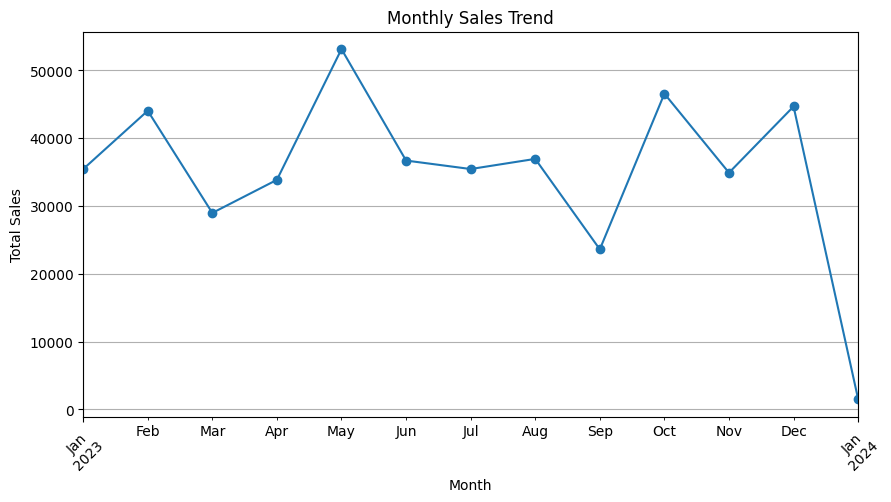

In [ ]:
import matplotlib.pyplot as plt

monthly_sales.plot(kind='line', marker='o', figsize=(10, 5))

plt.title('Monthly Sales Trend')
plt.xlabel('Month')
plt.ylabel('Total Sales')
plt.xticks(rotation=45)
plt.grid(True)
plt.show()

In [ ]:
# Quarterly Sales Trend

df['Quarter'] = df['Date'].dt.to_period('Q')

quarterly_sales = df.groupby('Quarter')['Total Amount'].sum()

print(quarterly_sales)

Quarter
2023Q1    108500
2023Q2    123735
2023Q3     96045
2023Q4    126190
2024Q1      1530
Freq: Q-DEC, Name: Total Amount, dtype: int64


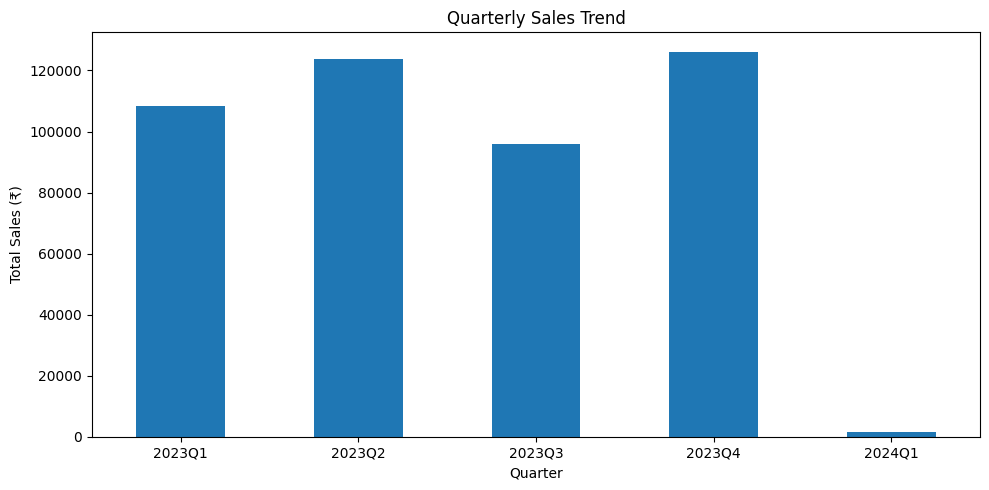

In [ ]:
# Quarterly Sales Trend Chart

quarterly_sales.plot(
    kind='bar',
    figsize=(10, 5),
    title='Quarterly Sales Trend',
    xlabel='Quarter',
    ylabel='Total Sales (₹)'
)

plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

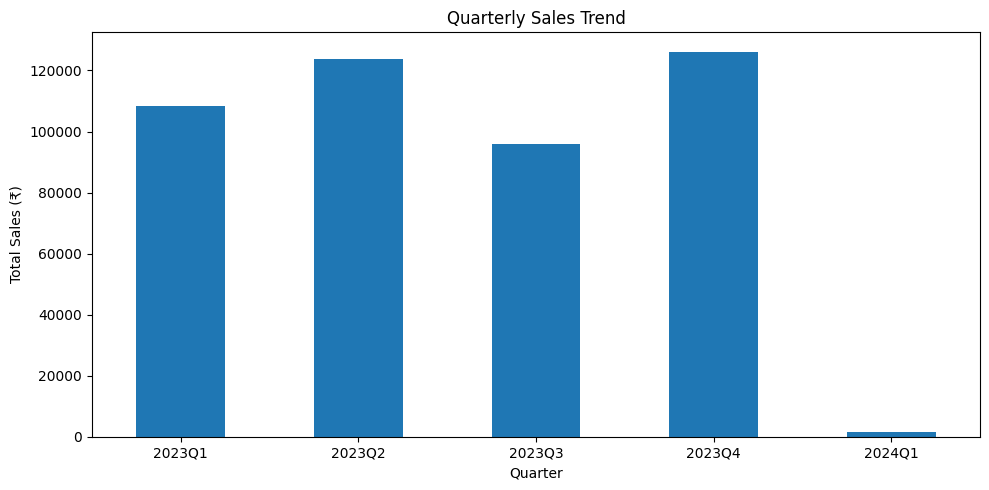

In [ ]:
# Quarterly Sales Trend Chart

quarterly_sales.plot(
    kind='bar',
    figsize=(10, 5),
    title='Quarterly Sales Trend',
    xlabel='Quarter',
    ylabel='Total Sales (₹)'
)

plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

### Observation – Quarterly Sales Trend

- Q4 2023 recorded the highest quarterly sales, with total sales of Rs. 1,26,190.
- Q3 2023 recorded the lowest sales among the complete quarters of 2023, with Rs. 96,045.
- Sales increased from Q1 to Q2 2023, decreased in Q3, and increased again in Q4.
- Q1 2024 shows only Rs. 1,530 because the dataset contains only partial January 2024 data, so it should not be compared directly with the complete 2023 quarters.

In [6]:
import pandas as pd

In [8]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [9]:
import os

print(os.listdir('/content/drive/MyDrive'))

['Colab Notebooks', 'IMG_20241211_092923.jpg', 'Student_Declaration_Form_akash[1][1].docx', 'inbound111876960796203468.webp', 'Give this in pdf way.gdoc', 'Add 2nd photo in first photo behind the virat phot....gdoc', 'Blood Donor App 1.0.zip', 'app-release[1] (1).apk', 'app-release[1].apk', 'Portfolio.gsite', 'Create a photo using effect and everything from 1....gdoc', 'Akash_B_Data_Analyst_Resume_One_Page (1).gdoc', 'Akash_B_Data_Analyst_Resume_One_Page.gdoc', 'Akash_B_Data_Analyst_Resume_COMPLETE_1_PAGE.pdf', 'Copy of SQL Interview Preparation.pdf']


In [10]:
from google.colab import files

uploaded = files.upload()

Saving retail_sales_dataset.csv to retail_sales_dataset.csv


In [11]:
import pandas as pd

filename = next(iter(uploaded))
df = pd.read_csv(filename)

print(df.shape)
df.head()

(1000, 9)


,Transaction ID,Date,Customer ID,Gender,Age,Product Category,Quantity,Price per Unit,Total Amount
0,1,2023-11-24,CUST001,Male,34,Beauty,3,50,150
1,2,2023-02-27,CUST002,Female,26,Clothing,2,500,1000
2,3,2023-01-13,CUST003,Male,50,Electronics,1,30,30
3,4,2023-05-21,CUST004,Male,37,Clothing,1,500,500
4,5,2023-05-06,CUST005,Male,30,Beauty,2,50,100


In [12]:
df['Date'] = pd.to_datetime(df['Date'])

bins = [17, 24, 34, 44, 54, 64]
labels = ['18-24', '25-34', '35-44', '45-54', '55-64']

df['Age Group'] = pd.cut(df['Age'], bins=bins, labels=labels)

print(df['Age Group'].value_counts().sort_index())

Age Group
18-24    149
25-34    203
35-44    207
45-54    225
55-64    216
Name: count, dtype: int64


In [14]:
age_group_counts = df['Age Group'].value_counts().sort_index()

print(age_group_counts)

Age Group
18-24    149
25-34    203
35-44    207
45-54    225
55-64    216
Name: count, dtype: int64


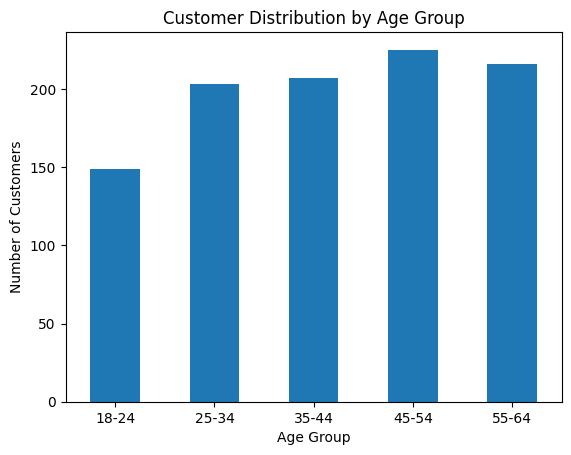

In [15]:
import matplotlib.pyplot as plt

age_group_counts.plot(kind='bar')

plt.title('Customer Distribution by Age Group')
plt.xlabel('Age Group')
plt.ylabel('Number of Customers')
plt.xticks(rotation=0)
plt.show()

### Observation – Customer Distribution by Age Group

- The 45–54 age group has the highest number of customers, with 225 customers.
- The 55–64 age group is the second-largest group, with 216 customers.
- The 18–24 age group has the lowest number of customers, with 149 customers.
- Overall, customers aged 25–64 make up the majority of the dataset.

In [16]:
gender_counts = df['Gender'].value_counts()

print(gender_counts)

Gender
Female    510
Male      490
Name: count, dtype: int64


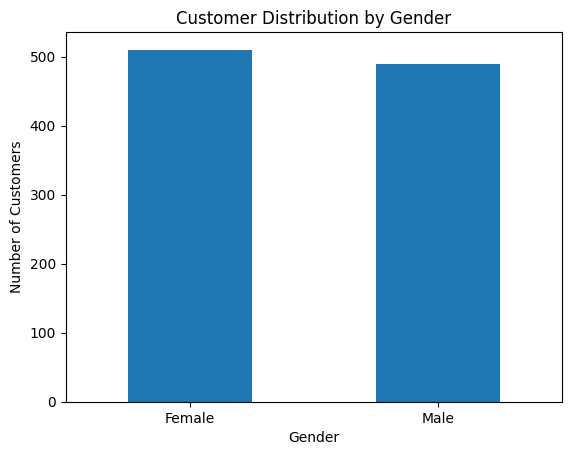

In [17]:
import matplotlib.pyplot as plt

gender_counts.plot(kind='bar')

plt.title('Customer Distribution by Gender')
plt.xlabel('Gender')
plt.ylabel('Number of Customers')
plt.xticks(rotation=0)
plt.show()

### Observation – Gender Distribution

- The dataset contains 510 female customers and 490 male customers.
- Female customers represent a slightly larger share of the dataset than male customers.
- Overall, the gender distribution is nearly balanced.

In [18]:
category_revenue = df.groupby('Product Category')['Total Amount'].sum().sort_values(ascending=False)

print(category_revenue)

Product Category
Electronics    156905
Clothing       155580
Beauty         143515
Name: Total Amount, dtype: int64


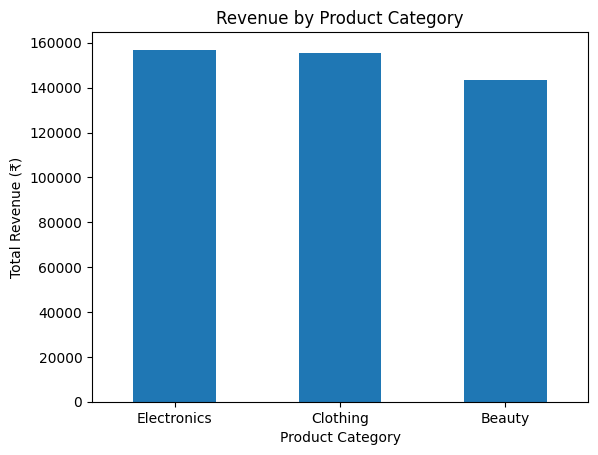

In [19]:
category_revenue.plot(kind='bar')

plt.title('Revenue by Product Category')
plt.xlabel('Product Category')
plt.ylabel('Total Revenue (₹)')
plt.xticks(rotation=0)
plt.show()

### Observation – Revenue by Product Category

- Electronics generated the highest revenue, with total sales of ₹1,56,905.
- Clothing generated ₹1,55,580, which is very close to Electronics.
- Beauty generated the lowest revenue among the three categories, with ₹1,43,515.
- The revenue difference between the categories is relatively small, indicating a fairly balanced contribution from all three categories.

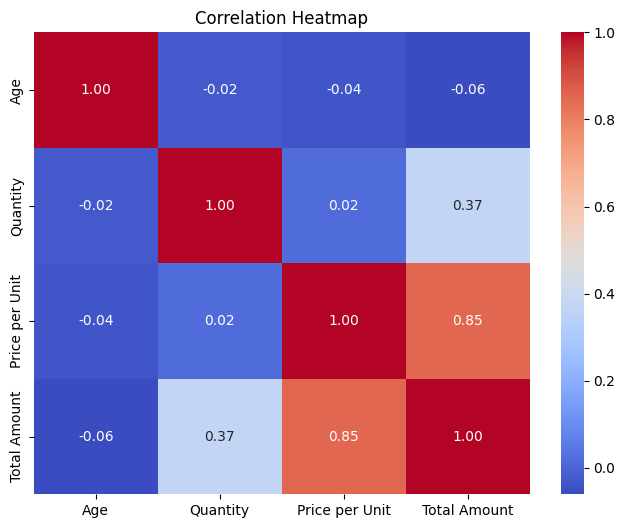

In [20]:
import seaborn as sns
import matplotlib.pyplot as plt

correlation = df[['Age', 'Quantity', 'Price per Unit', 'Total Amount']].corr()

plt.figure(figsize=(8, 6))
sns.heatmap(correlation, annot=True, cmap='coolwarm', fmt='.2f')

plt.title('Correlation Heatmap')
plt.show()

In [22]:
gender_sales = df.groupby('Gender')['Total Amount'].sum()

print(gender_sales)

Gender
Female    232840
Male      223160
Name: Total Amount, dtype: int64


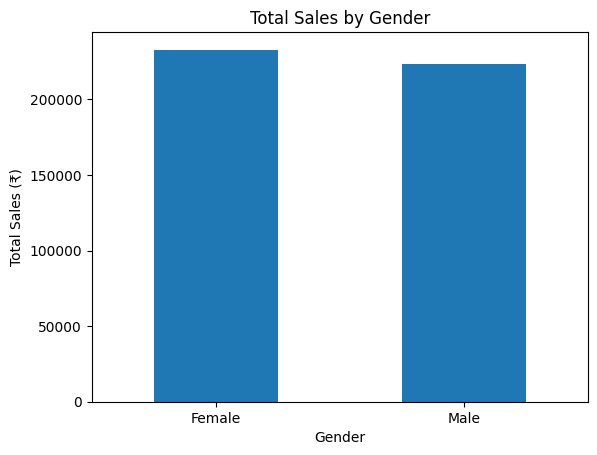

In [23]:
gender_sales.plot(kind='bar')

plt.title('Total Sales by Gender')
plt.xlabel('Gender')
plt.ylabel('Total Sales (₹)')
plt.xticks(rotation=0)
plt.show()

### Observation – Sales by Gender

* Female customers generated the highest total sales of ₹2,32,840.
* Male customers generated total sales of ₹2,23,160.
* Female sales were ₹9,680 higher than male sales.
* Overall, sales were fairly balanced between the two genders.


In [24]:
monthly_sales = df.groupby(df['Date'].dt.to_period('M'))['Total Amount'].sum()

print(monthly_sales)

Date
2023-01    35450
2023-02    44060
2023-03    28990
2023-04    33870
2023-05    53150
2023-06    36715
2023-07    35465
2023-08    36960
2023-09    23620
2023-10    46580
2023-11    34920
2023-12    44690
2024-01     1530
Freq: M, Name: Total Amount, dtype: int64


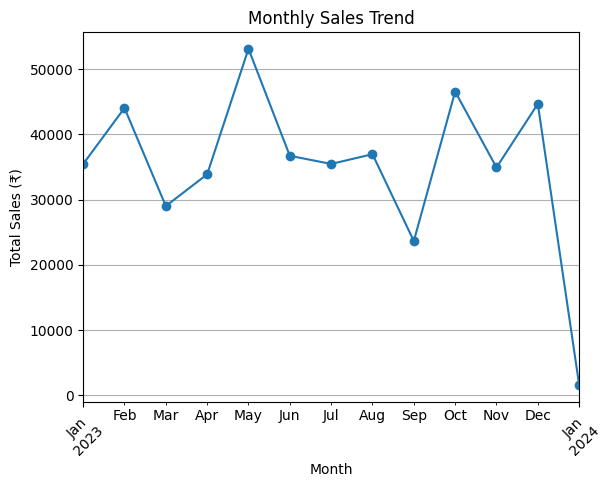

In [25]:
monthly_sales.plot(kind='line', marker='o')

plt.title('Monthly Sales Trend')
plt.xlabel('Month')
plt.ylabel('Total Sales (₹)')
plt.xticks(rotation=45)
plt.grid(True)
plt.show()

### Observation – Monthly Sales Trend

* Sales fluctuated throughout 2023, showing no consistent upward or downward trend.
* May 2023 recorded the highest monthly sales at ₹53,150.
* September 2023 recorded the lowest monthly sales in 2023 at ₹23,620.
* Sales increased again in October 2023 to ₹46,580.
* January 2024 recorded ₹1,530, but this appears to be a partial month in the dataset, so it should not be directly compared with the complete months of 2023.


In [26]:
age_bins = [0, 18, 25, 35, 45, 55, 65, 100]
age_labels = ['Under 18', '18-25', '26-35', '36-45', '46-55', '56-65', '65+']

df['Age Group'] = pd.cut(df['Age'], bins=age_bins, labels=age_labels)

age_group_sales = df.groupby('Age Group', observed=True)['Total Amount'].sum()

print(age_group_sales)

Age Group
Under 18     11215
18-25        73335
26-35        98480
36-45        91870
46-55       100690
56-65        80410
Name: Total Amount, dtype: int64


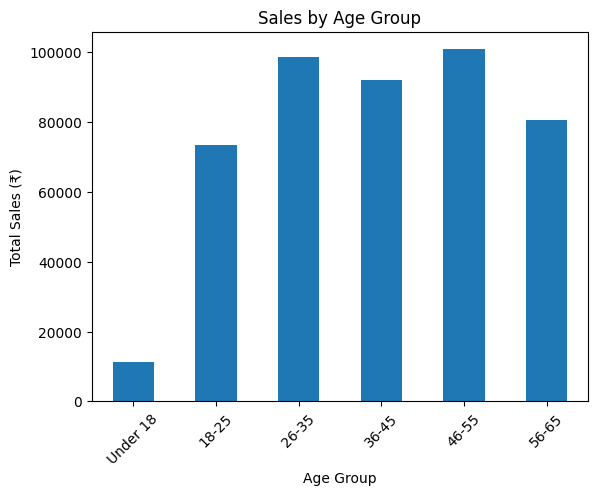

In [27]:
age_group_sales.plot(kind='bar')

plt.title('Sales by Age Group')
plt.xlabel('Age Group')
plt.ylabel('Total Sales (₹)')
plt.xticks(rotation=45)
plt.show()

### Observation – Sales by Age Group

* The 46–55 age group generated the highest sales at ₹1,00,690.
* The 26–35 age group generated ₹98,480, followed by the 36–45 age group with ₹91,870.
* The 56–65 age group contributed ₹80,410 in sales.
* The 18–25 age group generated ₹73,335.
* Customers under 18 generated the lowest sales at ₹11,215.
* No customers aged 65+ were present in the dataset.


In [28]:
category_quantity = df.groupby('Product Category')['Quantity'].sum().sort_values(ascending=False)

print(category_quantity)

Product Category
Clothing       894
Electronics    849
Beauty         771
Name: Quantity, dtype: int64


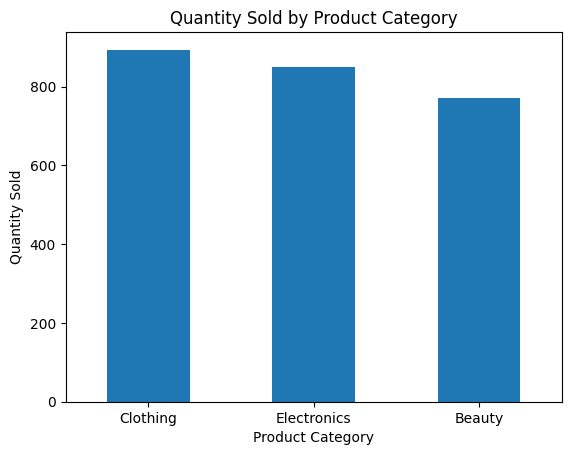

In [29]:
category_quantity.plot(kind='bar')

plt.title('Quantity Sold by Product Category')
plt.xlabel('Product Category')
plt.ylabel('Quantity Sold')
plt.xticks(rotation=0)
plt.show()

### Observation – Quantity Sold by Product Category

* Clothing had the highest quantity sold, with 894 units.
* Electronics had 849 units sold.
* Beauty had the lowest quantity sold, with 771 units.
* Clothing sold 123 more units than Beauty.
* The quantities sold across the three categories were relatively close.


In [30]:
avg_spending_gender = df.groupby('Gender')['Total Amount'].mean()

print(avg_spending_gender)

Gender
Female    456.549020
Male      455.428571
Name: Total Amount, dtype: float64


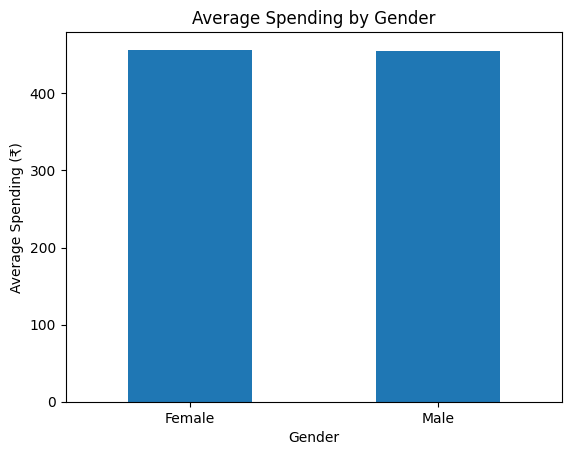

In [31]:
avg_spending_gender.plot(kind='bar')

plt.title('Average Spending by Gender')
plt.xlabel('Gender')
plt.ylabel('Average Spending (₹)')
plt.xticks(rotation=0)
plt.show()

### Observation – Average Spending by Gender

* Female customers had an average spending of ₹456.55 per transaction.
* Male customers had an average spending of ₹455.43 per transaction.
* The difference in average spending was only about ₹1.12.
* This indicates that the average transaction value was very similar for both genders.


In [32]:
avg_category_sales = df.groupby('Product Category')['Total Amount'].mean().sort_values(ascending=False)

print(avg_category_sales)

Product Category
Beauty         467.475570
Electronics    458.786550
Clothing       443.247863
Name: Total Amount, dtype: float64


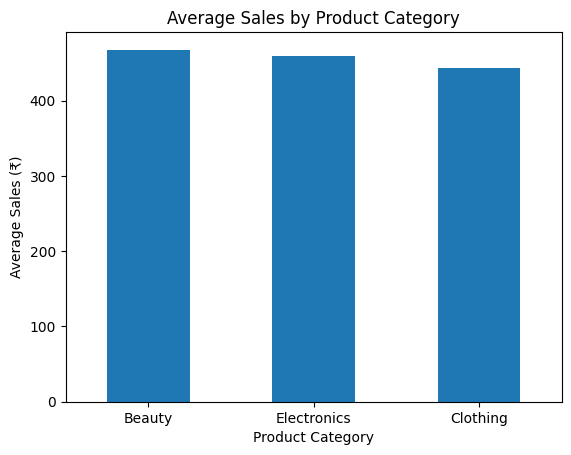

In [33]:
avg_category_sales.plot(kind='bar')

plt.title('Average Sales by Product Category')
plt.xlabel('Product Category')
plt.ylabel('Average Sales (₹)')
plt.xticks(rotation=0)
plt.show()

### Observation – Average Sales by Product Category

* Beauty had the highest average transaction amount at ₹467.48.
* Electronics had an average transaction amount of ₹458.79.
* Clothing had the lowest average transaction amount at ₹443.25.
* The difference between the highest and lowest average transaction amounts was about ₹24.23.
* Overall, the average transaction values across the three categories were relatively similar.


In [34]:
category_count = df.groupby('Product Category')['Customer ID'].nunique().sort_values(ascending=False)

print(category_count)

Product Category
Clothing       351
Electronics    342
Beauty         307
Name: Customer ID, dtype: int64


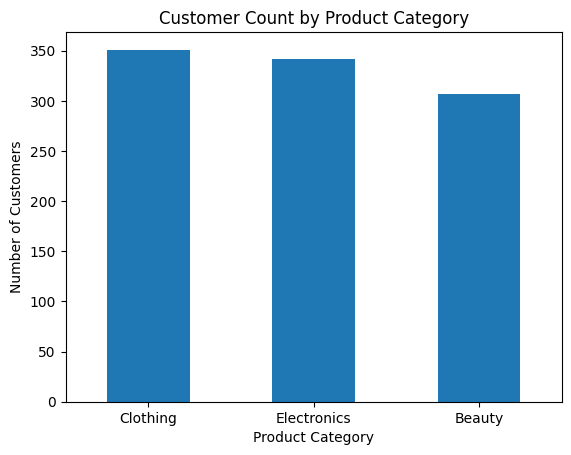

In [35]:
category_count.plot(kind='bar')

plt.title('Customer Count by Product Category')
plt.xlabel('Product Category')
plt.ylabel('Number of Customers')
plt.xticks(rotation=0)
plt.show()

### Observation – Customer Count by Product Category

* Clothing had the highest number of unique customers, with 351 customers.
* Electronics had 342 unique customers.
* Beauty had the lowest number of unique customers, with 307 customers.
* The number of customers across the three categories was relatively balanced.
* Clothing had 44 more unique customers than Beauty.


In [36]:
gender_sales = df.groupby('Gender')['Total Amount'].sum()

gender_sales

,Total Amount
Gender,
Female,232840
Male,223160


### Observation – Total Sales by Gender

* Female customers generated total sales of ₹232,840.
* Male customers generated total sales of ₹223,160.
* Female customers contributed slightly higher total sales than male customers.
* The difference in total sales between female and male customers was ₹9,680.


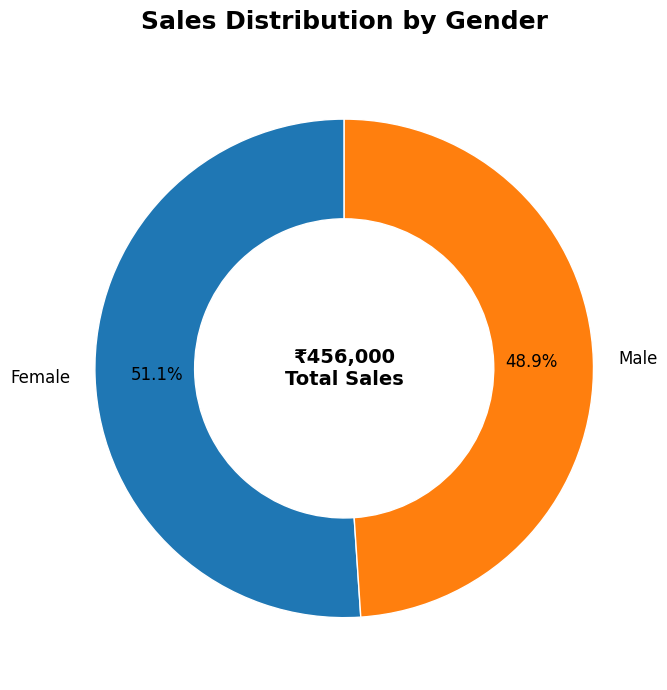

In [40]:
import matplotlib.pyplot as plt

# Create donut chart
plt.figure(figsize=(7, 7))

plt.pie(
    gender_sales.values,
    labels=gender_sales.index,
    autopct='%1.1f%%',
    startangle=90,
    pctdistance=0.75,
    wedgeprops=dict(width=0.4, edgecolor='white'),
    textprops={'fontsize': 12}
)

# Center text
total_sales = gender_sales.sum()

plt.text(
    0, 0,
    f'₹{total_sales:,.0f}\nTotal Sales',
    ha='center',
    va='center',
    fontsize=14,
    fontweight='bold'
)

plt.title(
    'Sales Distribution by Gender',
    fontsize=18,
    fontweight='bold',
    pad=20
)

plt.tight_layout()
plt.show()

In [41]:
age_group_sales = df.groupby('Age Group')['Total Amount'].sum()

age_group_sales

/tmp/ipykernel_1969/2675483783.py:1: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  age_group_sales = df.groupby('Age Group')['Total Amount'].sum()


,Total Amount
Age Group,
Under 18,11215
18-25,73335
26-35,98480
36-45,91870
46-55,100690
56-65,80410
65+,0


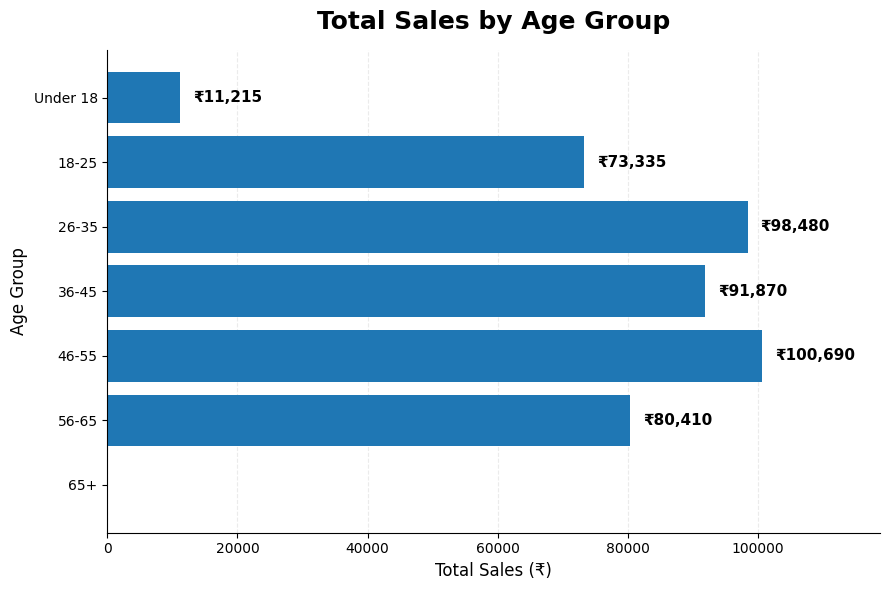

In [42]:
import matplotlib.pyplot as plt

plt.figure(figsize=(9, 6))

bars = plt.barh(
    age_group_sales.index,
    age_group_sales.values
)

plt.title(
    'Total Sales by Age Group',
    fontsize=18,
    fontweight='bold',
    pad=15
)

plt.xlabel('Total Sales (₹)', fontsize=12)
plt.ylabel('Age Group', fontsize=12)

# Add values
for bar in bars:
    width = bar.get_width()
    if width > 0:
        plt.text(
            width + 2000,
            bar.get_y() + bar.get_height() / 2,
            f'₹{width:,.0f}',
            va='center',
            fontsize=11,
            fontweight='bold'
        )

# Put youngest group at the top
plt.gca().invert_yaxis()

# Clean appearance
plt.gca().spines['top'].set_visible(False)
plt.gca().spines['right'].set_visible(False)

plt.grid(axis='x', linestyle='--', alpha=0.25)
plt.gca().set_axisbelow(True)

plt.xlim(0, age_group_sales.max() * 1.18)

plt.tight_layout()
plt.show()

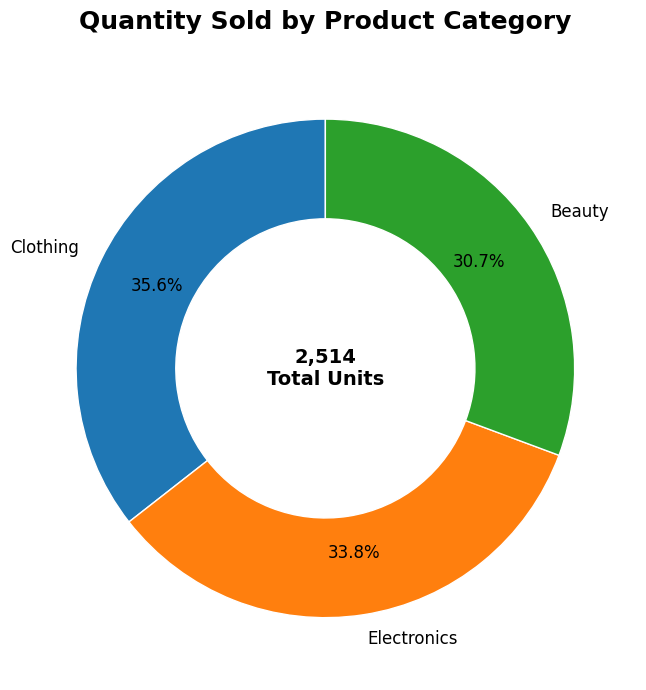

In [43]:
import matplotlib.pyplot as plt

plt.figure(figsize=(7, 7))

plt.pie(
    category_quantity.values,
    labels=category_quantity.index,
    autopct='%1.1f%%',
    startangle=90,
    pctdistance=0.75,
    wedgeprops=dict(width=0.4, edgecolor='white'),
    textprops={'fontsize': 12}
)

total_quantity = category_quantity.sum()

plt.text(
    0, 0,
    f'{total_quantity:,}\nTotal Units',
    ha='center',
    va='center',
    fontsize=14,
    fontweight='bold'
)

plt.title(
    'Quantity Sold by Product Category',
    fontsize=18,
    fontweight='bold',
    pad=20
)

plt.tight_layout()
plt.show()

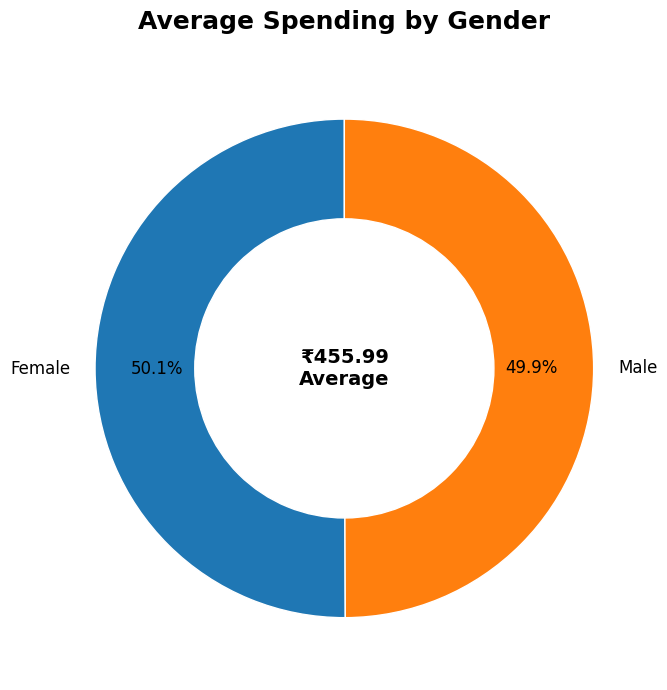

In [44]:
import matplotlib.pyplot as plt

plt.figure(figsize=(7, 7))

plt.pie(
    avg_spending_gender.values,
    labels=avg_spending_gender.index,
    autopct='%1.1f%%',
    startangle=90,
    pctdistance=0.75,
    wedgeprops=dict(width=0.4, edgecolor='white'),
    textprops={'fontsize': 12}
)

plt.text(
    0, 0,
    f'₹{avg_spending_gender.mean():,.2f}\nAverage',
    ha='center',
    va='center',
    fontsize=14,
    fontweight='bold'
)

plt.title(
    'Average Spending by Gender',
    fontsize=18,
    fontweight='bold',
    pad=20
)

plt.tight_layout()
plt.show()

In [47]:
avg_transaction_category = df.groupby('Product Category')['Total Amount'].mean()

avg_transaction_category

,Total Amount
Product Category,
Beauty,467.475570
Clothing,443.247863
Electronics,458.786550


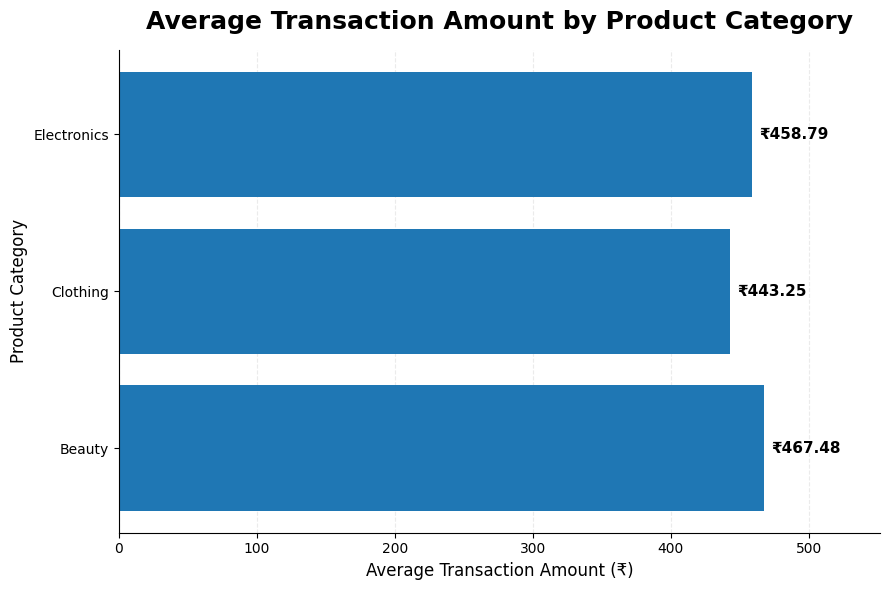

In [48]:
import matplotlib.pyplot as plt

plt.figure(figsize=(9, 6))

bars = plt.barh(
    avg_transaction_category.index,
    avg_transaction_category.values
)

plt.title(
    'Average Transaction Amount by Product Category',
    fontsize=18,
    fontweight='bold',
    pad=15
)

plt.xlabel('Average Transaction Amount (₹)', fontsize=12)
plt.ylabel('Product Category', fontsize=12)

for bar in bars:
    width = bar.get_width()
    plt.text(
        width + 5,
        bar.get_y() + bar.get_height() / 2,
        f'₹{width:,.2f}',
        va='center',
        fontsize=11,
        fontweight='bold'
    )

plt.gca().spines['top'].set_visible(False)
plt.gca().spines['right'].set_visible(False)

plt.grid(axis='x', linestyle='--', alpha=0.25)
plt.gca().set_axisbelow(True)

plt.xlim(0, avg_transaction_category.max() * 1.18)

plt.tight_layout()
plt.show()

### Observation – Average Transaction Amount by Product Category

* Beauty had the highest average transaction amount at approximately **₹467.48**.
* Electronics had an average transaction amount of approximately **₹458.79**.
* Clothing had the lowest average transaction amount at approximately **₹443.25**.
* The difference between the highest and lowest average transaction amounts was relatively small, showing that the average spending per transaction was fairly similar across all three categories.


In [49]:
gender_customers = df.groupby('Gender')['Customer ID'].nunique()

gender_customers

,Customer ID
Gender,
Female,510
Male,490


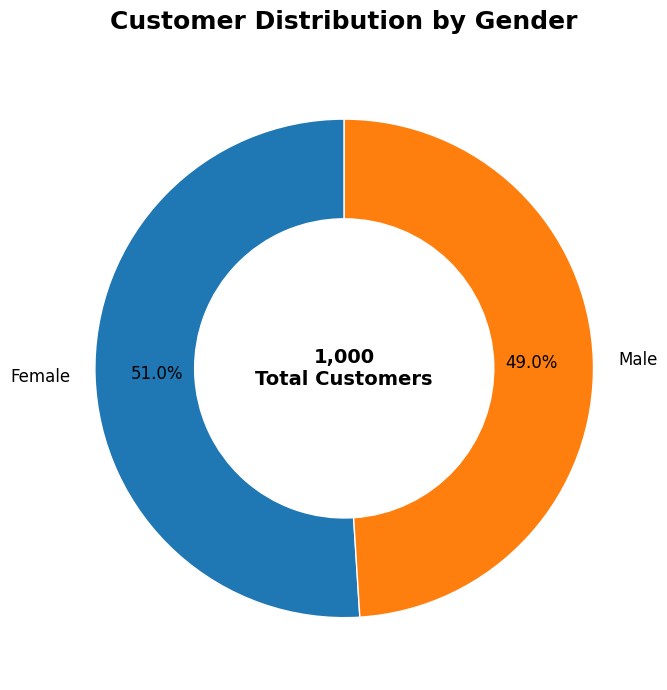

In [50]:
import matplotlib.pyplot as plt

plt.figure(figsize=(7, 7))

plt.pie(
    gender_customers.values,
    labels=gender_customers.index,
    autopct='%1.1f%%',
    startangle=90,
    pctdistance=0.75,
    wedgeprops=dict(width=0.4, edgecolor='white'),
    textprops={'fontsize': 12}
)

total_customers = gender_customers.sum()

plt.text(
    0, 0,
    f'{total_customers:,}\nTotal Customers',
    ha='center',
    va='center',
    fontsize=14,
    fontweight='bold'
)

plt.title(
    'Customer Distribution by Gender',
    fontsize=18,
    fontweight='bold',
    pad=20
)

plt.tight_layout()
plt.show()

In [51]:
avg_spending_age = df.groupby('Age Group')['Total Amount'].mean()

avg_spending_age

/tmp/ipykernel_1969/1737506336.py:1: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  avg_spending_age = df.groupby('Age Group')['Total Amount'].mean()


,Total Amount
Age Group,
Under 18,534.047619
18-25,495.506757
26-35,480.390244
36-45,454.801980
46-55,439.694323
56-65,412.358974
65+,NaN


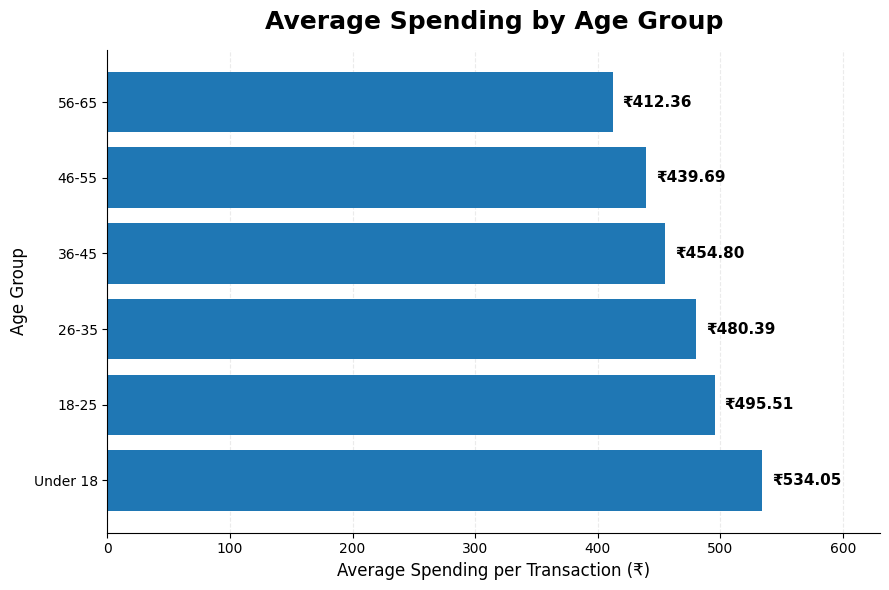

In [52]:
import matplotlib.pyplot as plt

# Remove age groups with no data
avg_spending_age_clean = avg_spending_age.dropna()

plt.figure(figsize=(9, 6))

bars = plt.barh(
    avg_spending_age_clean.index,
    avg_spending_age_clean.values
)

plt.title(
    'Average Spending by Age Group',
    fontsize=18,
    fontweight='bold',
    pad=15
)

plt.xlabel('Average Spending per Transaction (₹)', fontsize=12)
plt.ylabel('Age Group', fontsize=12)

# Add values
for bar in bars:
    width = bar.get_width()
    plt.text(
        width + 8,
        bar.get_y() + bar.get_height() / 2,
        f'₹{width:,.2f}',
        va='center',
        fontsize=11,
        fontweight='bold'
    )

# Clean appearance
plt.gca().spines['top'].set_visible(False)
plt.gca().spines['right'].set_visible(False)

plt.grid(axis='x', linestyle='--', alpha=0.25)
plt.gca().set_axisbelow(True)

plt.xlim(0, avg_spending_age_clean.max() * 1.18)

plt.tight_layout()
plt.show()

In [53]:
gender_quantity = df.groupby('Gender')['Quantity'].sum()

gender_quantity

,Quantity
Gender,
Female,1298
Male,1216


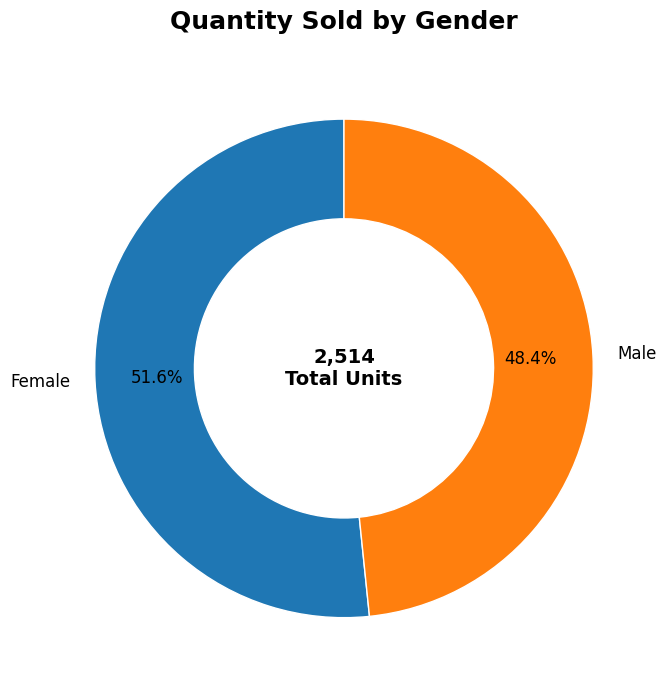

In [54]:
import matplotlib.pyplot as plt

plt.figure(figsize=(7, 7))

plt.pie(
    gender_quantity.values,
    labels=gender_quantity.index,
    autopct='%1.1f%%',
    startangle=90,
    pctdistance=0.75,
    wedgeprops=dict(width=0.4, edgecolor='white'),
    textprops={'fontsize': 12}
)

total_quantity = gender_quantity.sum()

plt.text(
    0, 0,
    f'{total_quantity:,}\nTotal Units',
    ha='center',
    va='center',
    fontsize=14,
    fontweight='bold'
)

plt.title(
    'Quantity Sold by Gender',
    fontsize=18,
    fontweight='bold',
    pad=20
)

plt.tight_layout()
plt.show()

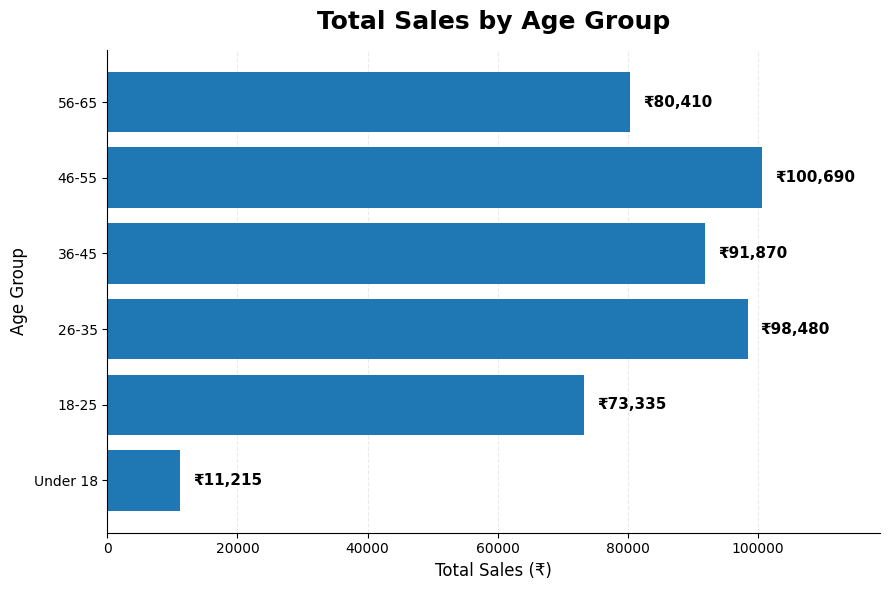

In [55]:
import matplotlib.pyplot as plt

# Remove the empty 65+ group
age_sales_clean = age_group_sales[age_group_sales > 0]

plt.figure(figsize=(9, 6))

bars = plt.barh(
    age_sales_clean.index,
    age_sales_clean.values
)

plt.title(
    'Total Sales by Age Group',
    fontsize=18,
    fontweight='bold',
    pad=15
)

plt.xlabel('Total Sales (₹)', fontsize=12)
plt.ylabel('Age Group', fontsize=12)

# Add values
for bar in bars:
    width = bar.get_width()
    plt.text(
        width + 2000,
        bar.get_y() + bar.get_height() / 2,
        f'₹{width:,.0f}',
        va='center',
        fontsize=11,
        fontweight='bold'
    )

# Clean appearance
plt.gca().spines['top'].set_visible(False)
plt.gca().spines['right'].set_visible(False)

plt.grid(axis='x', linestyle='--', alpha=0.25)
plt.gca().set_axisbelow(True)

plt.xlim(0, age_sales_clean.max() * 1.18)

plt.tight_layout()
plt.show()

In [56]:
monthly_sales = df.groupby(df['Date'].dt.to_period('M'))['Total Amount'].sum()

monthly_sales

,Total Amount
Date,
2023-01,35450
2023-02,44060
2023-03,28990
2023-04,33870
2023-05,53150
2023-06,36715
2023-07,35465
2023-08,36960
2023-09,23620


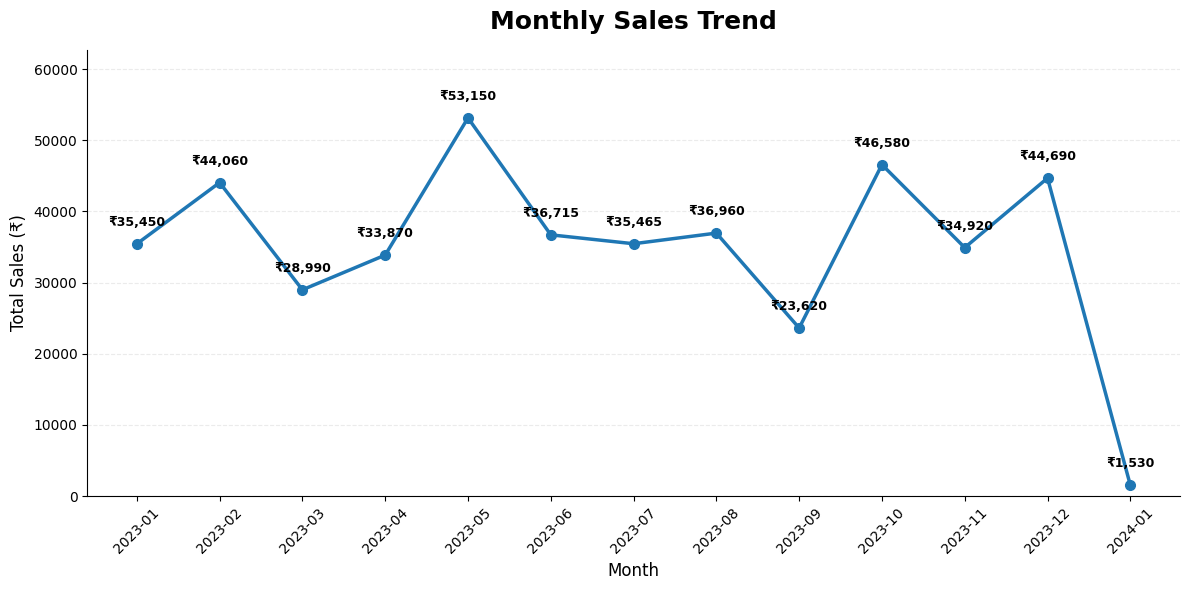

In [57]:
import matplotlib.pyplot as plt

# Convert Period index to string for plotting
months = monthly_sales.index.astype(str)
sales = monthly_sales.values

plt.figure(figsize=(12, 6))

plt.plot(
    months,
    sales,
    marker='o',
    linewidth=2.5,
    markersize=7
)

plt.title(
    'Monthly Sales Trend',
    fontsize=18,
    fontweight='bold',
    pad=15
)

plt.xlabel('Month', fontsize=12)
plt.ylabel('Total Sales (₹)', fontsize=12)

# Display values above points
for i, value in enumerate(sales):
    plt.text(
        i,
        value + 2500,
        f'₹{value:,.0f}',
        ha='center',
        fontsize=9,
        fontweight='bold'
    )

plt.xticks(rotation=45)
plt.grid(axis='y', linestyle='--', alpha=0.25)

plt.gca().spines['top'].set_visible(False)
plt.gca().spines['right'].set_visible(False)

plt.ylim(0, max(sales) * 1.18)

plt.tight_layout()
plt.show()

In [58]:
# Calculate quarterly sales
quarterly_sales = df.groupby(df['Date'].dt.to_period('Q'))['Total Amount'].sum()

print(quarterly_sales)

Date
2023Q1    108500
2023Q2    123735
2023Q3     96045
2023Q4    126190
2024Q1      1530
Freq: Q-DEC, Name: Total Amount, dtype: int64


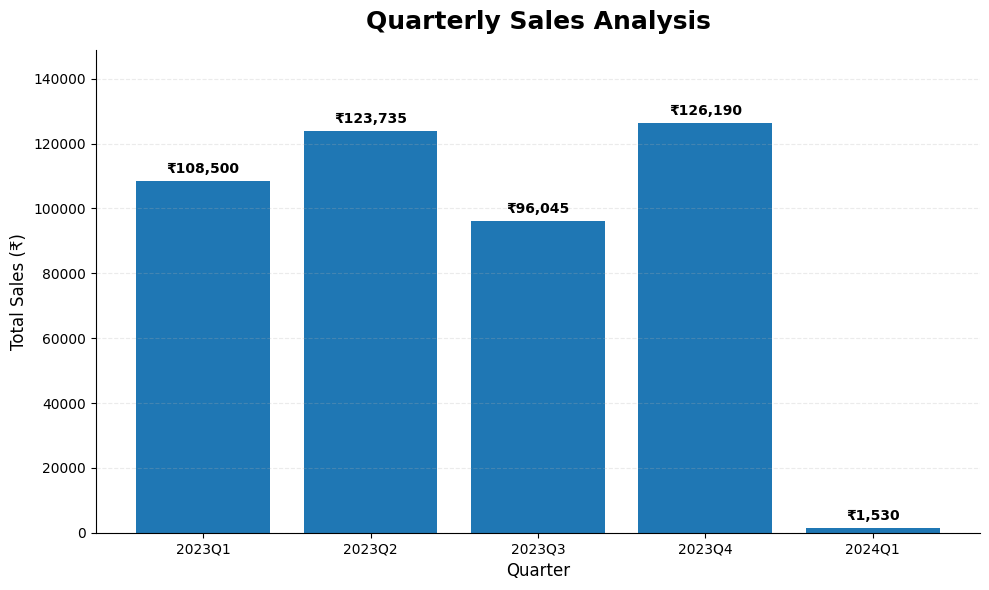

In [59]:
import matplotlib.pyplot as plt

# Convert quarterly periods to strings
quarters = quarterly_sales.index.astype(str)
sales = quarterly_sales.values

plt.figure(figsize=(10, 6))

bars = plt.bar(quarters, sales)

plt.title(
    'Quarterly Sales Analysis',
    fontsize=18,
    fontweight='bold',
    pad=15
)

plt.xlabel('Quarter', fontsize=12)
plt.ylabel('Total Sales (₹)', fontsize=12)

# Display values on top of bars
for bar, value in zip(bars, sales):
    plt.text(
        bar.get_x() + bar.get_width() / 2,
        value + 2500,
        f'₹{value:,.0f}',
        ha='center',
        fontsize=10,
        fontweight='bold'
    )

plt.grid(axis='y', linestyle='--', alpha=0.25)
plt.gca().spines['top'].set_visible(False)
plt.gca().spines['right'].set_visible(False)

plt.ylim(0, max(sales) * 1.18)

plt.tight_layout()
plt.show()

In [60]:
# Calculate total sales by gender
gender_sales = df.groupby('Gender')['Total Amount'].sum()

print(gender_sales)

Gender
Female    232840
Male      223160
Name: Total Amount, dtype: int64


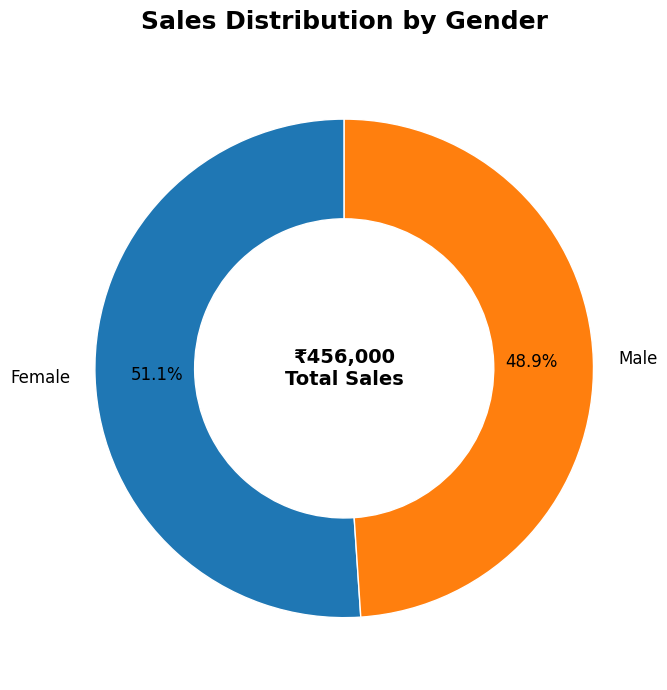

In [61]:
import matplotlib.pyplot as plt

# Get values
values = gender_sales.values
labels = gender_sales.index

# Calculate total sales
total_sales = gender_sales.sum()

plt.figure(figsize=(7, 7))

plt.pie(
    values,
    labels=labels,
    autopct='%1.1f%%',
    startangle=90,
    pctdistance=0.75,
    wedgeprops=dict(width=0.4, edgecolor='white'),
    textprops={'fontsize': 12}
)

# Center text
plt.text(
    0, 0,
    f'₹{total_sales:,.0f}\nTotal Sales',
    ha='center',
    va='center',
    fontsize=14,
    fontweight='bold'
)

plt.title(
    'Sales Distribution by Gender',
    fontsize=18,
    fontweight='bold',
    pad=20
)

plt.tight_layout()
plt.show()

In [62]:
# Calculate average spending by gender
gender_avg_spending = df.groupby('Gender')['Total Amount'].mean()

print(gender_avg_spending)

Gender
Female    456.549020
Male      455.428571
Name: Total Amount, dtype: float64


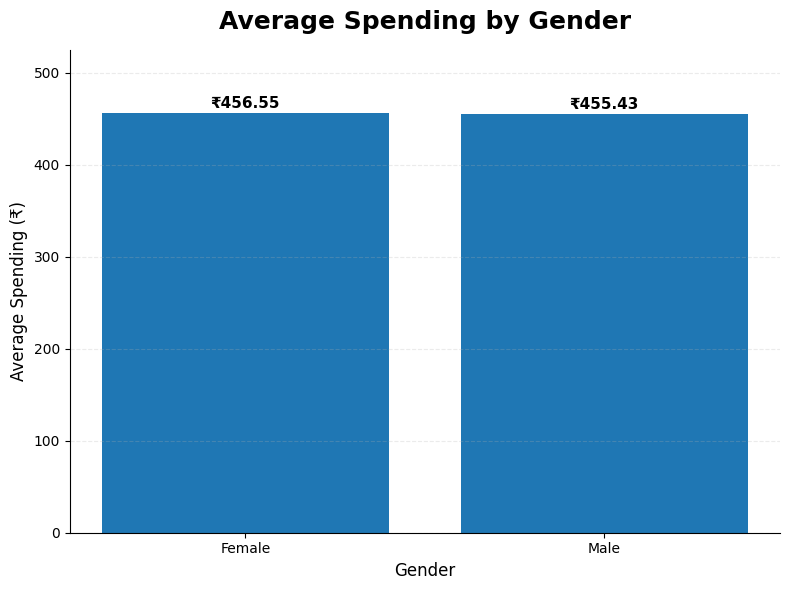

In [63]:
import matplotlib.pyplot as plt

labels = gender_avg_spending.index
values = gender_avg_spending.values

plt.figure(figsize=(8, 6))

bars = plt.bar(labels, values)

plt.title(
    'Average Spending by Gender',
    fontsize=18,
    fontweight='bold',
    pad=15
)

plt.xlabel('Gender', fontsize=12)
plt.ylabel('Average Spending (₹)', fontsize=12)

# Display values on bars
for bar, value in zip(bars, values):
    plt.text(
        bar.get_x() + bar.get_width() / 2,
        value + 5,
        f'₹{value:,.2f}',
        ha='center',
        fontsize=11,
        fontweight='bold'
    )

plt.grid(axis='y', linestyle='--', alpha=0.25)
plt.gca().spines['top'].set_visible(False)
plt.gca().spines['right'].set_visible(False)

plt.ylim(0, max(values) * 1.15)

plt.tight_layout()
plt.show()

In [64]:
# Calculate customer count by gender
gender_customer_count = df.groupby('Gender')['Customer ID'].nunique()

print(gender_customer_count)

Gender
Female    510
Male      490
Name: Customer ID, dtype: int64


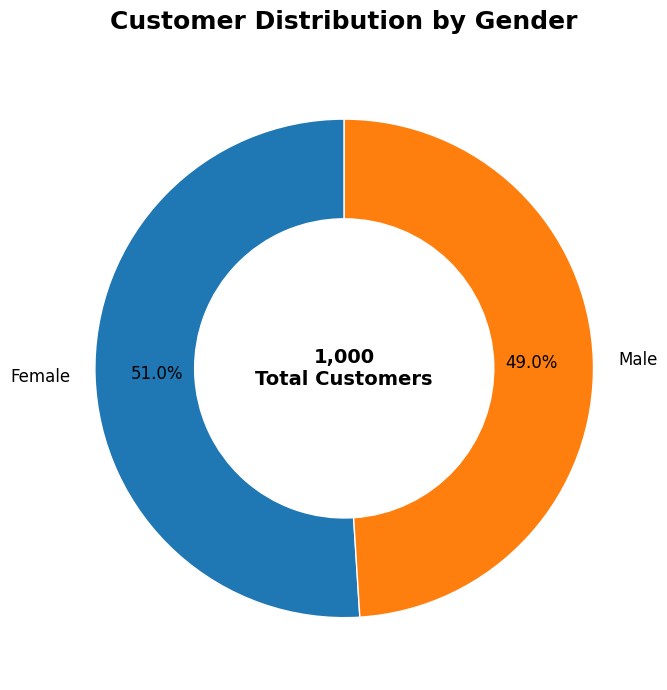

In [65]:
import matplotlib.pyplot as plt

# Get values
values = gender_customer_count.values
labels = gender_customer_count.index

# Calculate total customers
total_customers = gender_customer_count.sum()

plt.figure(figsize=(7, 7))

plt.pie(
    values,
    labels=labels,
    autopct='%1.1f%%',
    startangle=90,
    pctdistance=0.75,
    wedgeprops=dict(width=0.4, edgecolor='white'),
    textprops={'fontsize': 12}
)

# Center text
plt.text(
    0, 0,
    f'{total_customers:,}\nTotal Customers',
    ha='center',
    va='center',
    fontsize=14,
    fontweight='bold'
)

plt.title(
    'Customer Distribution by Gender',
    fontsize=18,
    fontweight='bold',
    pad=20
)

plt.tight_layout()
plt.show()

In [66]:
# Calculate total sales by product category
category_sales = df.groupby('Product Category')['Total Amount'].sum()

print(category_sales)

Product Category
Beauty         143515
Clothing       155580
Electronics    156905
Name: Total Amount, dtype: int64


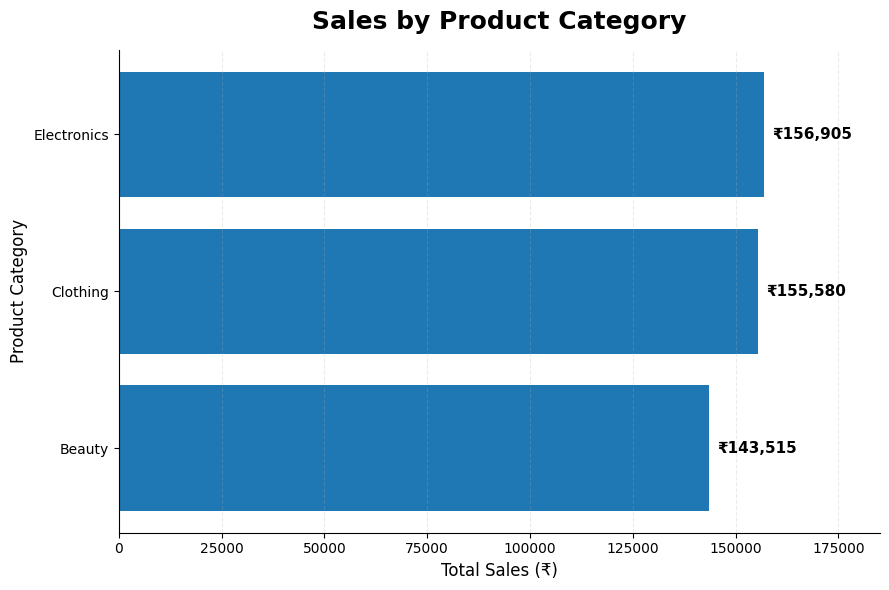

In [67]:
import matplotlib.pyplot as plt

# Sort categories from highest to lowest sales
category_sales_sorted = category_sales.sort_values(ascending=True)

plt.figure(figsize=(9, 6))

bars = plt.barh(
    category_sales_sorted.index,
    category_sales_sorted.values
)

plt.title(
    'Sales by Product Category',
    fontsize=18,
    fontweight='bold',
    pad=15
)

plt.xlabel('Total Sales (₹)', fontsize=12)
plt.ylabel('Product Category', fontsize=12)

# Display values on bars
for bar, value in zip(bars, category_sales_sorted.values):
    plt.text(
        value + 2000,
        bar.get_y() + bar.get_height() / 2,
        f'₹{value:,.0f}',
        va='center',
        fontsize=11,
        fontweight='bold'
    )

plt.grid(axis='x', linestyle='--', alpha=0.25)
plt.gca().spines['top'].set_visible(False)
plt.gca().spines['right'].set_visible(False)

plt.xlim(0, max(category_sales_sorted.values) * 1.18)

plt.tight_layout()
plt.show()

In [68]:
# Calculate total quantity sold by product category
category_quantity = df.groupby('Product Category')['Quantity'].sum()

print(category_quantity)

Product Category
Beauty         771
Clothing       894
Electronics    849
Name: Quantity, dtype: int64


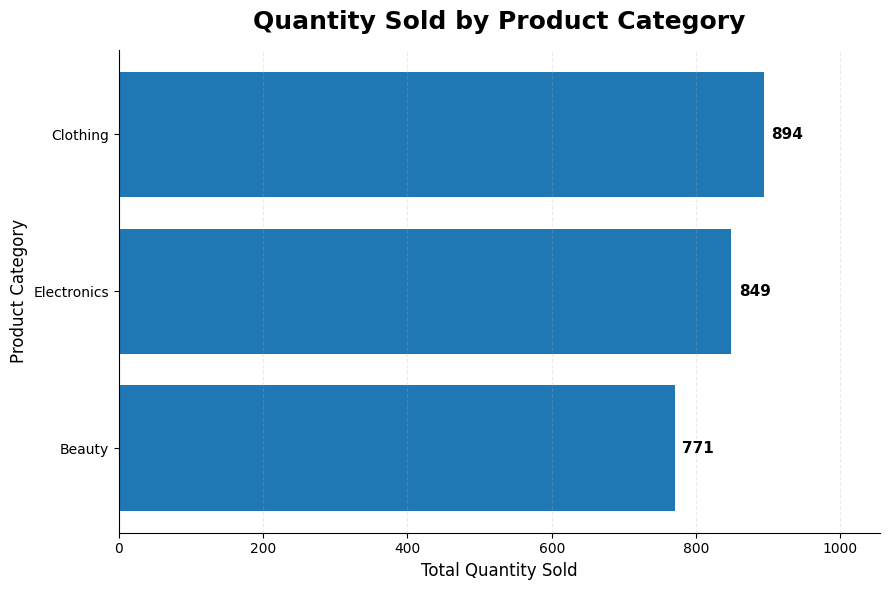

In [69]:
import matplotlib.pyplot as plt

# Sort categories from highest to lowest quantity
category_quantity_sorted = category_quantity.sort_values(ascending=True)

plt.figure(figsize=(9, 6))

bars = plt.barh(
    category_quantity_sorted.index,
    category_quantity_sorted.values
)

plt.title(
    'Quantity Sold by Product Category',
    fontsize=18,
    fontweight='bold',
    pad=15
)

plt.xlabel('Total Quantity Sold', fontsize=12)
plt.ylabel('Product Category', fontsize=12)

# Display values on bars
for bar, value in zip(bars, category_quantity_sorted.values):
    plt.text(
        value + 10,
        bar.get_y() + bar.get_height() / 2,
        f'{value:,}',
        va='center',
        fontsize=11,
        fontweight='bold'
    )

plt.grid(axis='x', linestyle='--', alpha=0.25)
plt.gca().spines['top'].set_visible(False)
plt.gca().spines['right'].set_visible(False)

plt.xlim(0, max(category_quantity_sorted.values) * 1.18)

plt.tight_layout()
plt.show()

In [70]:
avg_sales_category = df.groupby('Product Category')['Total Amount'].mean().sort_values(ascending=True)

print(avg_sales_category)

Product Category
Clothing       443.247863
Electronics    458.786550
Beauty         467.475570
Name: Total Amount, dtype: float64


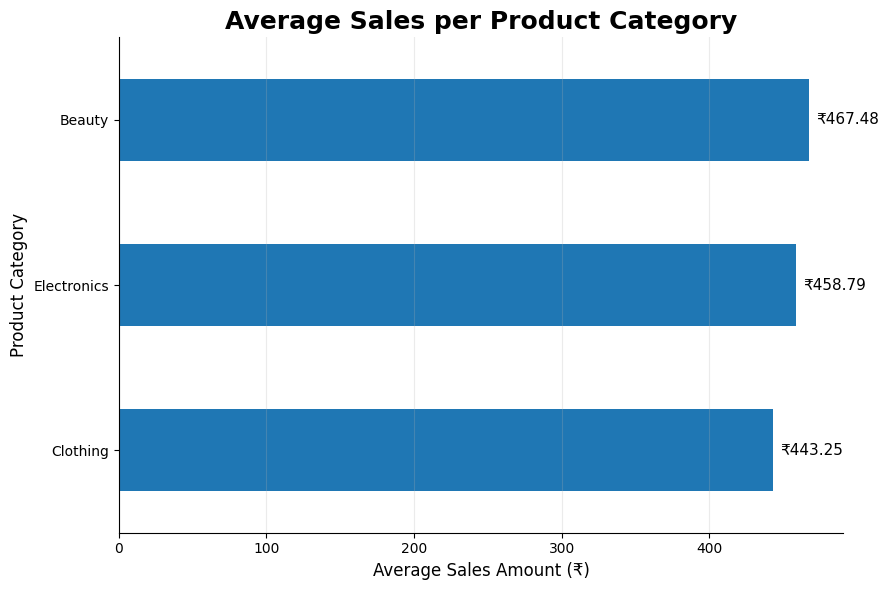

In [71]:
plt.figure(figsize=(9, 6))

avg_sales_category.plot(kind='barh')

plt.title('Average Sales per Product Category', fontsize=18, fontweight='bold')
plt.xlabel('Average Sales Amount (₹)', fontsize=12)
plt.ylabel('Product Category', fontsize=12)

for i, value in enumerate(avg_sales_category):
    plt.text(value + 5, i, f'₹{value:,.2f}', va='center', fontsize=11)

plt.grid(axis='x', alpha=0.25)
plt.gca().spines['top'].set_visible(False)
plt.gca().spines['right'].set_visible(False)

plt.tight_layout()
plt.show()

In [72]:
customer_category = df.groupby('Product Category')['Customer ID'].nunique().sort_values(ascending=True)

print(customer_category)

Product Category
Beauty         307
Electronics    342
Clothing       351
Name: Customer ID, dtype: int64


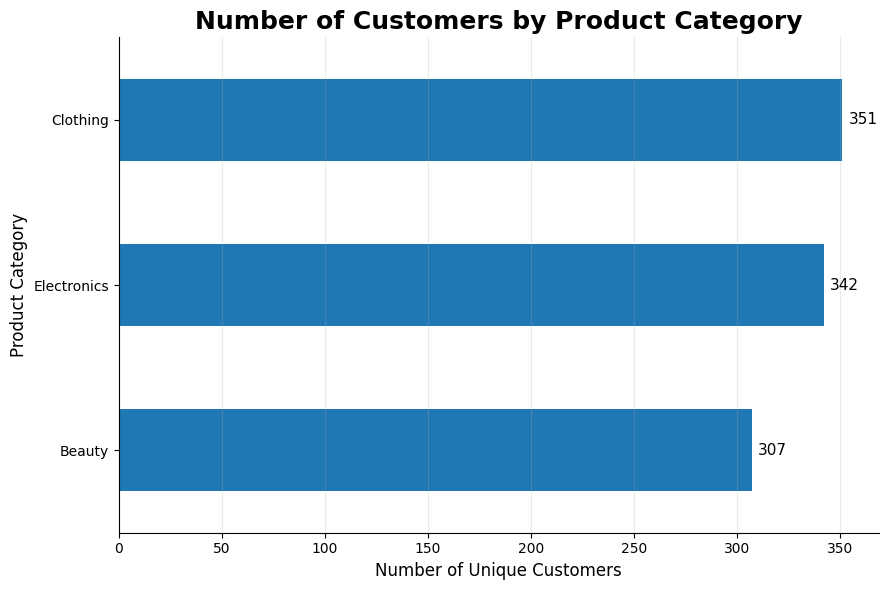

In [73]:
plt.figure(figsize=(9, 6))

customer_category.plot(kind='barh')

plt.title('Number of Customers by Product Category', fontsize=18, fontweight='bold')
plt.xlabel('Number of Unique Customers', fontsize=12)
plt.ylabel('Product Category', fontsize=12)

for i, value in enumerate(customer_category):
    plt.text(value + 3, i, f'{value:,}', va='center', fontsize=11)

plt.grid(axis='x', alpha=0.25)
plt.gca().spines['top'].set_visible(False)
plt.gca().spines['right'].set_visible(False)

plt.tight_layout()
plt.show()

In [74]:
age_sales = df.groupby('Age Group', observed=False)['Total Amount'].sum()

print(age_sales)

Age Group
Under 18     11215
18-25        73335
26-35        98480
36-45        91870
46-55       100690
56-65        80410
65+              0
Name: Total Amount, dtype: int64


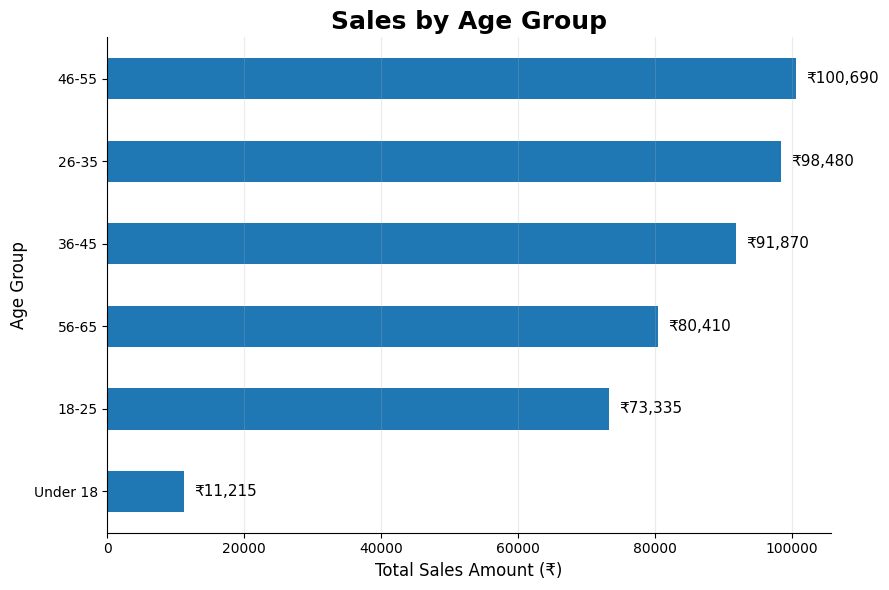

In [75]:
age_sales_chart = age_sales[age_sales > 0].sort_values(ascending=True)

plt.figure(figsize=(9, 6))

age_sales_chart.plot(kind='barh')

plt.title('Sales by Age Group', fontsize=18, fontweight='bold')
plt.xlabel('Total Sales Amount (₹)', fontsize=12)
plt.ylabel('Age Group', fontsize=12)

for i, value in enumerate(age_sales_chart):
    plt.text(value + 1500, i, f'₹{value:,.0f}', va='center', fontsize=11)

plt.grid(axis='x', alpha=0.25)
plt.gca().spines['top'].set_visible(False)
plt.gca().spines['right'].set_visible(False)

plt.tight_layout()
plt.show()

In [76]:
avg_age_sales = df.groupby('Age Group', observed=False)['Total Amount'].mean()

print(avg_age_sales)

Age Group
Under 18    534.047619
18-25       495.506757
26-35       480.390244
36-45       454.801980
46-55       439.694323
56-65       412.358974
65+                NaN
Name: Total Amount, dtype: float64


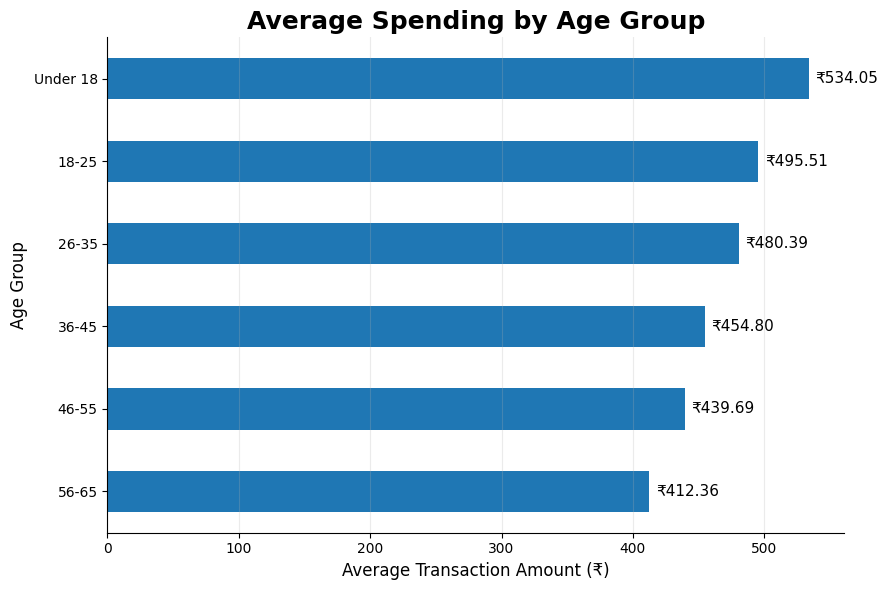

In [77]:
avg_age_sales_chart = avg_age_sales.dropna().sort_values(ascending=True)

plt.figure(figsize=(9, 6))

avg_age_sales_chart.plot(kind='barh')

plt.title('Average Spending by Age Group', fontsize=18, fontweight='bold')
plt.xlabel('Average Transaction Amount (₹)', fontsize=12)
plt.ylabel('Age Group', fontsize=12)

for i, value in enumerate(avg_age_sales_chart):
    plt.text(value + 5, i, f'₹{value:,.2f}', va='center', fontsize=11)

plt.grid(axis='x', alpha=0.25)
plt.gca().spines['top'].set_visible(False)
plt.gca().spines['right'].set_visible(False)

plt.tight_layout()
plt.show()

In [78]:
quantity_sales = df.groupby('Quantity')['Total Amount'].sum().sort_index()

print(quantity_sales)


Quantity
1     44805
2     81050
3    144285
4    185860
Name: Total Amount, dtype: int64


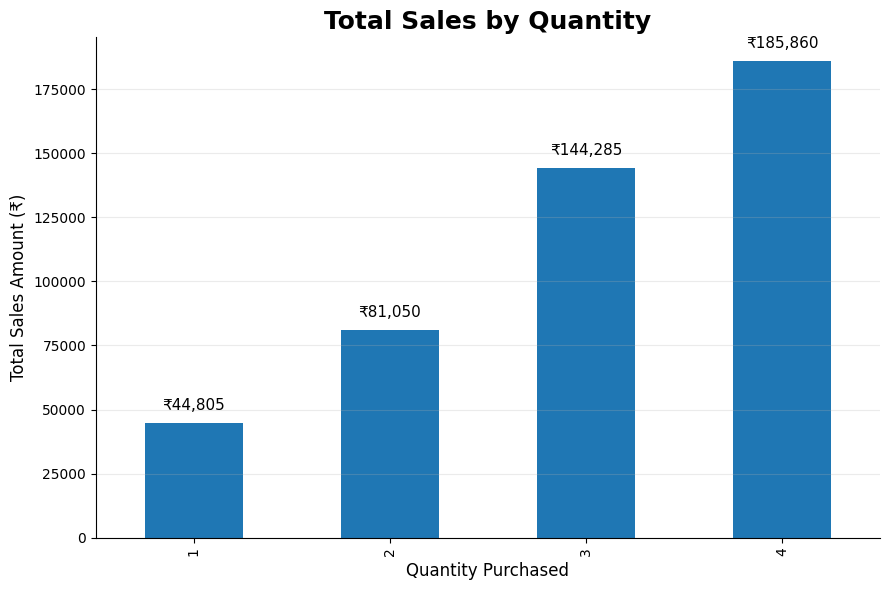

In [79]:
plt.figure(figsize=(9, 6))

quantity_sales.plot(kind='bar')

plt.title('Total Sales by Quantity', fontsize=18, fontweight='bold')
plt.xlabel('Quantity Purchased', fontsize=12)
plt.ylabel('Total Sales Amount (₹)', fontsize=12)

for i, value in enumerate(quantity_sales):
    plt.text(i, value + 5000, f'₹{value:,.0f}', ha='center', fontsize=11)

plt.grid(axis='y', alpha=0.25)
plt.gca().spines['top'].set_visible(False)
plt.gca().spines['right'].set_visible(False)

plt.tight_layout()
plt.show()

In [80]:
avg_quantity_sales = df.groupby('Quantity')['Total Amount'].mean()

print(avg_quantity_sales)

Quantity
1    177.094862
2    333.539095
3    598.692946
4    706.692015
Name: Total Amount, dtype: float64


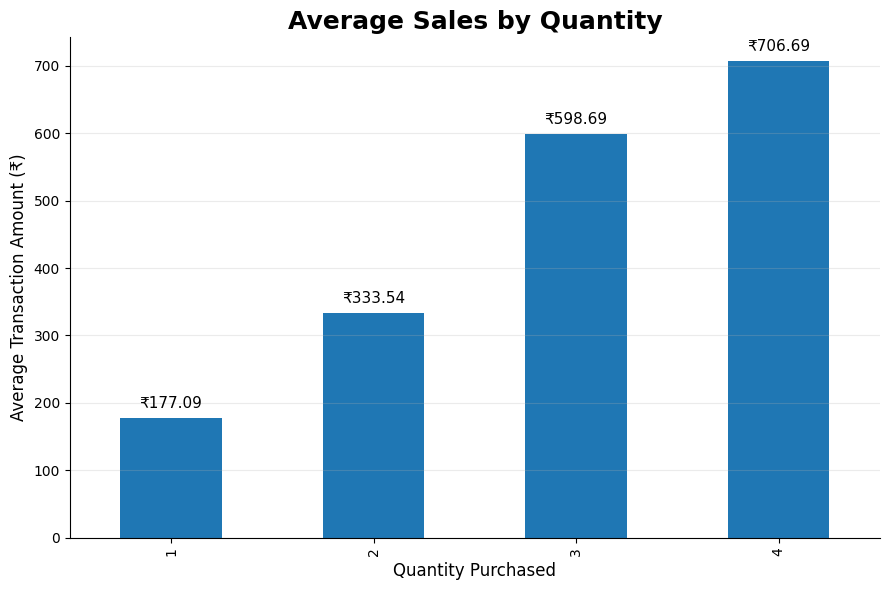

In [81]:
plt.figure(figsize=(9, 6))

avg_quantity_sales.plot(kind='bar')

plt.title('Average Sales by Quantity', fontsize=18, fontweight='bold')
plt.xlabel('Quantity Purchased', fontsize=12)
plt.ylabel('Average Transaction Amount (₹)', fontsize=12)

for i, value in enumerate(avg_quantity_sales):
    plt.text(i, value + 15, f'₹{value:,.2f}', ha='center', fontsize=11)

plt.grid(axis='y', alpha=0.25)
plt.gca().spines['top'].set_visible(False)
plt.gca().spines['right'].set_visible(False)

plt.tight_layout()
plt.show()

In [82]:
price_sales = df.groupby('Price per Unit')['Total Amount'].sum().sort_index()

print(price_sales)

Price per Unit
25      13050
30      13350
50      26700
300    155400
500    247500
Name: Total Amount, dtype: int64


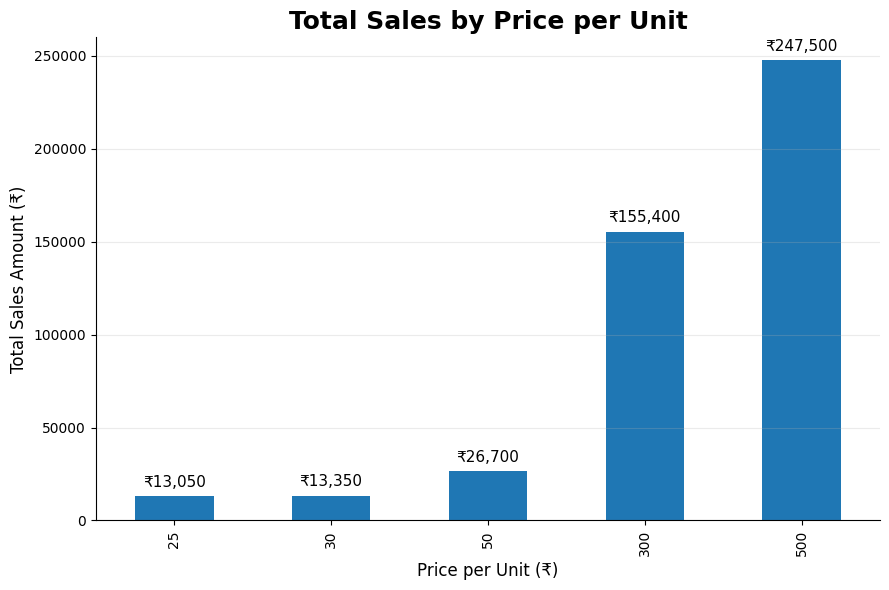

In [83]:
plt.figure(figsize=(9, 6))

price_sales.plot(kind='bar')

plt.title('Total Sales by Price per Unit', fontsize=18, fontweight='bold')
plt.xlabel('Price per Unit (₹)', fontsize=12)
plt.ylabel('Total Sales Amount (₹)', fontsize=12)

for i, value in enumerate(price_sales):
    plt.text(i, value + 5000, f'₹{value:,.0f}', ha='center', fontsize=11)

plt.grid(axis='y', alpha=0.25)
plt.gca().spines['top'].set_visible(False)
plt.gca().spines['right'].set_visible(False)

plt.tight_layout()
plt.show()

In [84]:
avg_price_sales = df.groupby('Price per Unit')['Total Amount'].mean().sort_index()

print(avg_price_sales)

Price per Unit
25       62.142857
30       72.950820
50      126.540284
300     788.832487
500    1243.718593
Name: Total Amount, dtype: float64


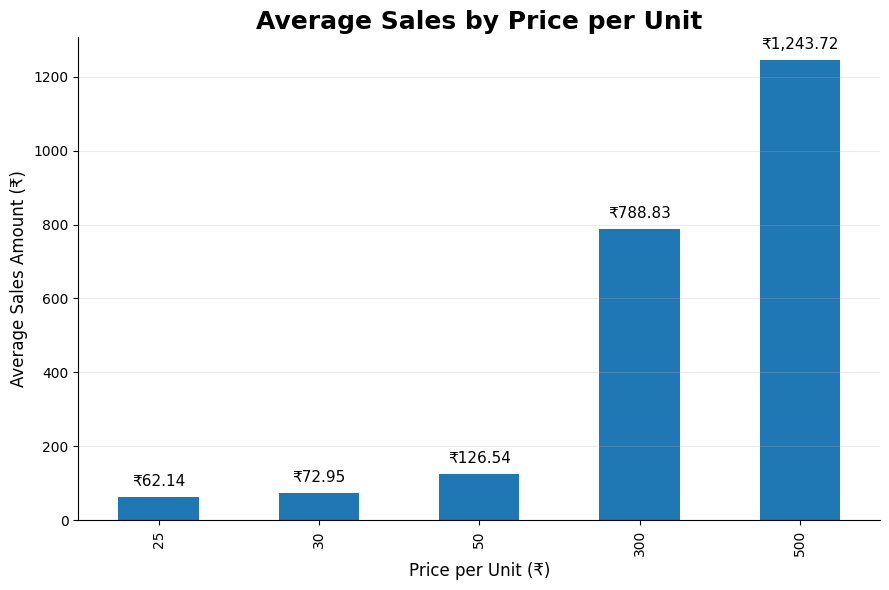

In [85]:
plt.figure(figsize=(9, 6))

avg_price_sales.plot(kind='bar')

plt.title('Average Sales by Price per Unit', fontsize=18, fontweight='bold')
plt.xlabel('Price per Unit (₹)', fontsize=12)
plt.ylabel('Average Sales Amount (₹)', fontsize=12)

for i, value in enumerate(avg_price_sales):
    plt.text(i, value + 30, f'₹{value:,.2f}', ha='center', fontsize=11)

plt.grid(axis='y', alpha=0.25)
plt.gca().spines['top'].set_visible(False)
plt.gca().spines['right'].set_visible(False)

plt.tight_layout()
plt.show()

In [86]:
age_sales = df.groupby('Age')['Total Amount'].sum().sort_index()

print(age_sales)

Age
18    11215
19    14870
20     8645
21    12585
22    13700
23     8220
24     5415
25     9900
26    13980
27     9385
28     8670
29     6570
30     9790
31    10220
32     5550
33     6240
34    16785
35    11290
36     9105
37    11650
38    11100
39     4595
40     9415
41     5650
42     8500
43    17970
44     7560
45     6325
46    13090
47    12505
48     7240
49     5110
50     9845
51    16065
52     7040
53     9510
54    10505
55     9780
56     9440
57     9290
58     7395
59     9470
60    11590
61     6730
62     8120
63     9250
64     9125
Name: Total Amount, dtype: int64


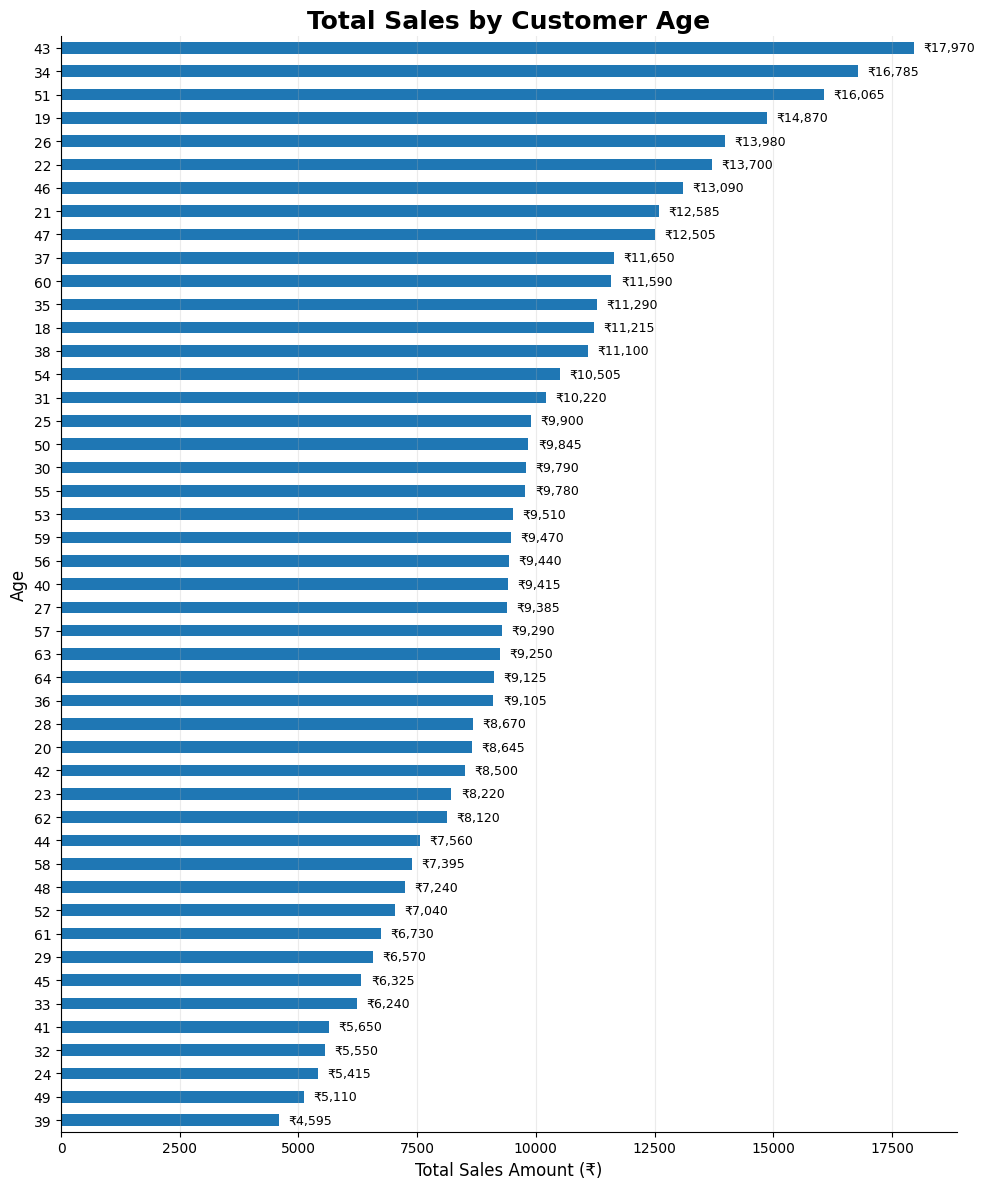

In [87]:
plt.figure(figsize=(10, 12))

age_sales.sort_values().plot(kind='barh')

plt.title('Total Sales by Customer Age', fontsize=18, fontweight='bold')
plt.xlabel('Total Sales Amount (₹)', fontsize=12)
plt.ylabel('Age', fontsize=12)

for i, value in enumerate(age_sales.sort_values()):
    plt.text(value + 200, i, f'₹{value:,.0f}', va='center', fontsize=9)

plt.grid(axis='x', alpha=0.25)
plt.gca().spines['top'].set_visible(False)
plt.gca().spines['right'].set_visible(False)

plt.tight_layout()
plt.show()

In [88]:
avg_age_sales = df.groupby('Age')['Total Amount'].mean().sort_index()

print(avg_age_sales)

Age
18    534.047619
19    708.095238
20    411.666667
21    629.250000
22    507.407407
23    342.500000
24    361.000000
25    495.000000
26    635.454545
27    408.043478
28    412.857143
29    410.625000
30    445.000000
31    464.545455
32    292.105263
33    624.000000
34    599.464286
35    513.181818
36    607.000000
37    728.125000
38    584.210526
39    255.277778
40    392.291667
41    269.047619
42    326.923077
43    579.677419
44    504.000000
45    372.058824
46    523.600000
47    480.961538
48    402.222222
49    268.947368
50    428.043478
51    535.500000
52    320.000000
53    559.411765
54    375.178571
55    465.714286
56    496.842105
57    309.666667
58    528.214286
59    557.058824
60    526.818182
61    373.888889
62    300.740741
63    544.117647
64    294.354839
Name: Total Amount, dtype: float64


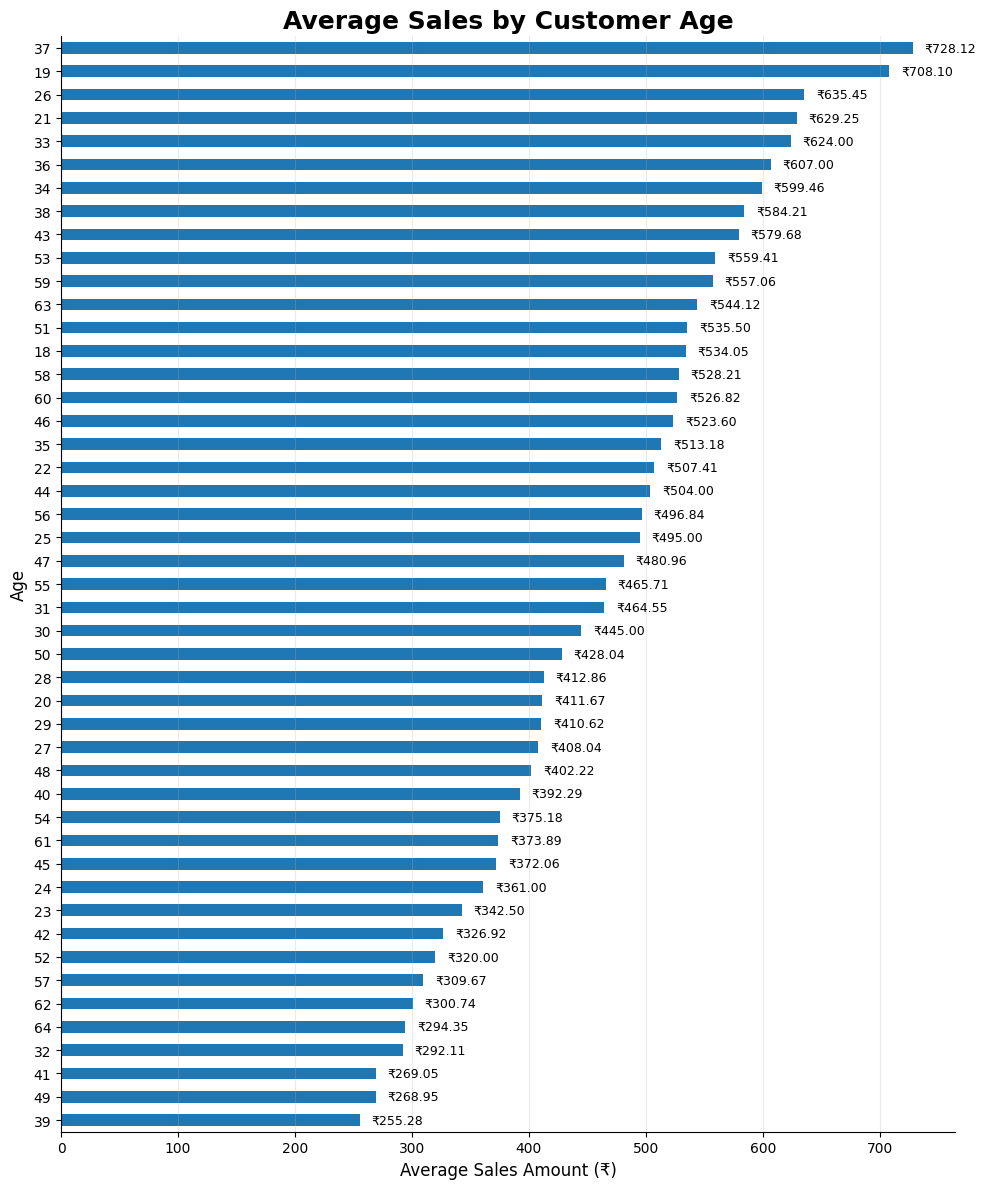

In [89]:
plt.figure(figsize=(10, 12))

avg_age_sales.sort_values().plot(kind='barh')

plt.title('Average Sales by Customer Age', fontsize=18, fontweight='bold')
plt.xlabel('Average Sales Amount (₹)', fontsize=12)
plt.ylabel('Age', fontsize=12)

for i, value in enumerate(avg_age_sales.sort_values()):
    plt.text(value + 10, i, f'₹{value:,.2f}', va='center', fontsize=9)

plt.grid(axis='x', alpha=0.25)
plt.gca().spines['top'].set_visible(False)
plt.gca().spines['right'].set_visible(False)

plt.tight_layout()
plt.show()

In [90]:
age_counts = df['Age'].value_counts().sort_index()

print(age_counts)

Age
18    21
19    21
20    21
21    20
22    27
23    24
24    15
25    20
26    22
27    23
28    21
29    16
30    22
31    22
32    19
33    10
34    28
35    22
36    15
37    16
38    19
39    18
40    24
41    21
42    26
43    31
44    15
45    17
46    25
47    26
48    18
49    19
50    23
51    30
52    22
53    17
54    28
55    21
56    19
57    30
58    14
59    17
60    22
61    18
62    27
63    17
64    31
Name: count, dtype: int64


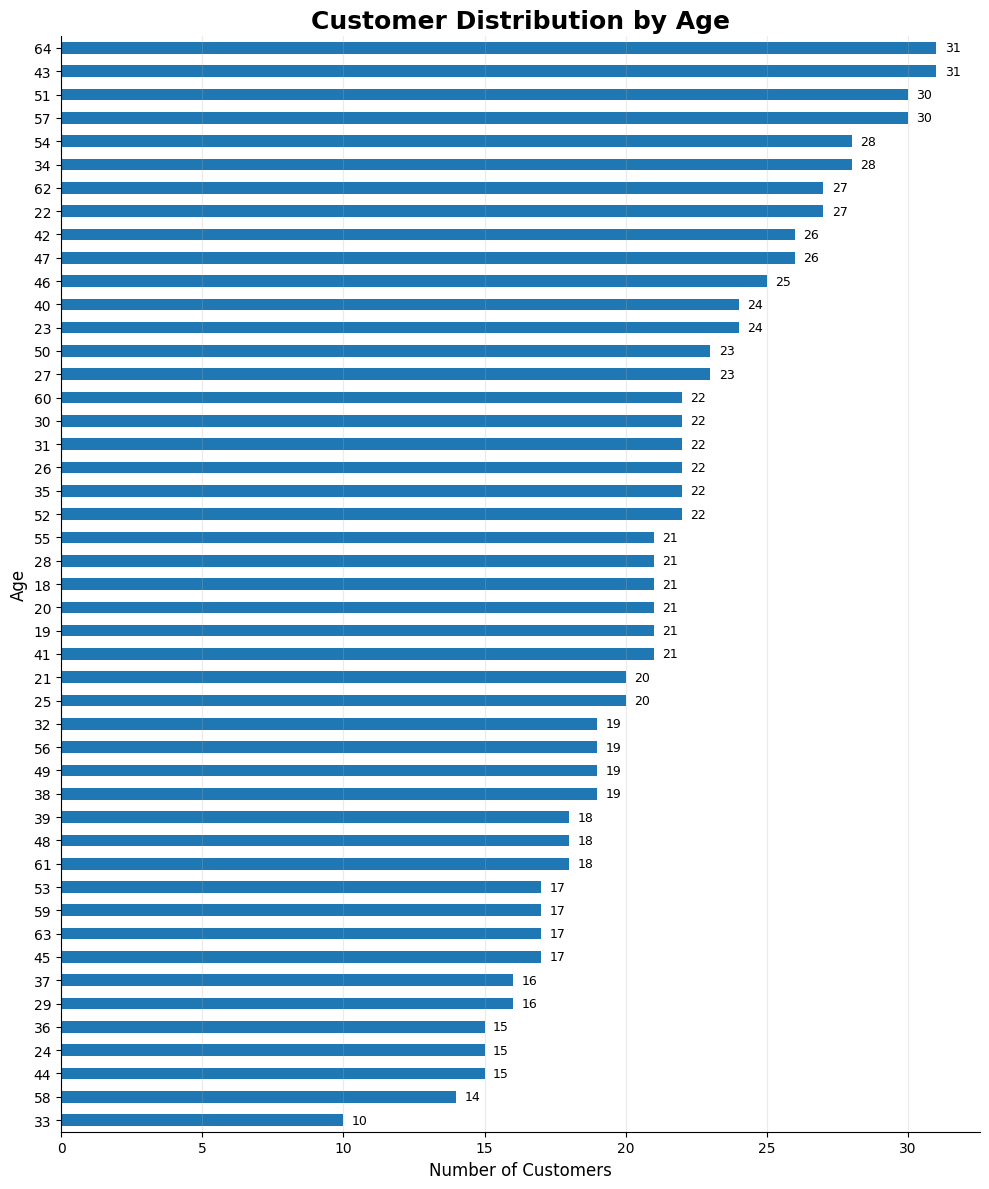

In [91]:
plt.figure(figsize=(10, 12))

age_counts.sort_values().plot(kind='barh')

plt.title('Customer Distribution by Age', fontsize=18, fontweight='bold')
plt.xlabel('Number of Customers', fontsize=12)
plt.ylabel('Age', fontsize=12)

for i, value in enumerate(age_counts.sort_values()):
    plt.text(value + 0.3, i, f'{value}', va='center', fontsize=9)

plt.grid(axis='x', alpha=0.25)
plt.gca().spines['top'].set_visible(False)
plt.gca().spines['right'].set_visible(False)

plt.tight_layout()
plt.show()

In [92]:
correlation = df[['Age', 'Quantity', 'Price per Unit', 'Total Amount']].corr()

print(correlation)

                     Age  Quantity  Price per Unit  Total Amount
Age             1.000000 -0.023737       -0.038423     -0.060568
Quantity       -0.023737  1.000000        0.017501      0.373707
Price per Unit -0.038423  0.017501        1.000000      0.851925
Total Amount   -0.060568  0.373707        0.851925      1.000000


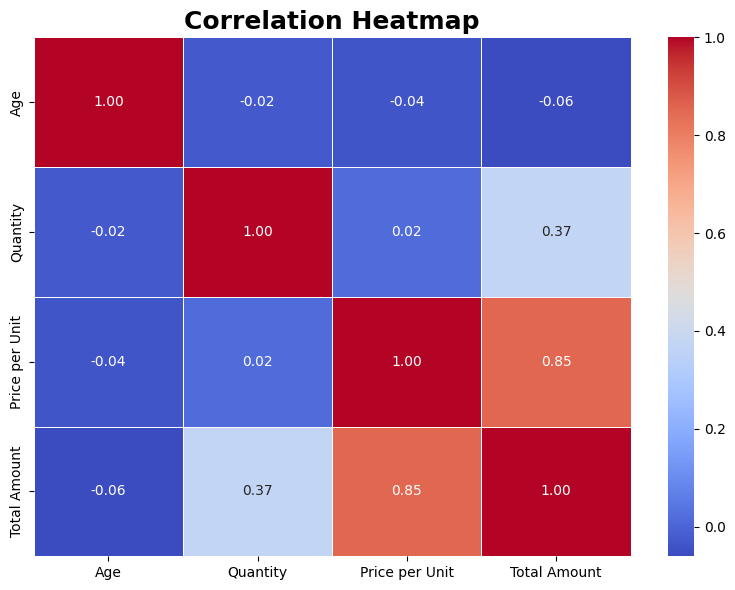

In [93]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(8, 6))

sns.heatmap(
    correlation,
    annot=True,
    cmap='coolwarm',
    fmt='.2f',
    linewidths=0.5
)

plt.title('Correlation Heatmap', fontsize=18, fontweight='bold')
plt.tight_layout()
plt.show()

In [94]:
missing_values = df.isnull().sum()

print(missing_values)

Transaction ID      0
Date                0
Customer ID         0
Gender              0
Age                 0
Product Category    0
Quantity            0
Price per Unit      0
Total Amount        0
Age Group           0
dtype: int64


In [95]:
duplicates = df.duplicated().sum()

print("Number of duplicate records:", duplicates)

Number of duplicate records: 0


In [96]:
print("Quantity <= 0:", (df['Quantity'] <= 0).sum())
print("Price per Unit <= 0:", (df['Price per Unit'] <= 0).sum())
print("Total Amount <= 0:", (df['Total Amount'] <= 0).sum())
print("Age <= 0:", (df['Age'] <= 0).sum())

Quantity <= 0: 0
Price per Unit <= 0: 0
Total Amount <= 0: 0
Age <= 0: 0


In [97]:
print("Start Date:", df['Date'].min())
print("End Date:", df['Date'].max())

Start Date: 2023-01-01 00:00:00
End Date: 2024-01-01 00:00:00


In [98]:
total_sales = df['Total Amount'].sum()

print(f"Total Sales: ₹{total_sales:,.2f}")

Total Sales: ₹456,000.00


In [99]:
total_transactions = df['Transaction ID'].nunique()

print("Total Transactions:", total_transactions)

Total Transactions: 1000


In [100]:
average_transaction = df['Total Amount'].mean()

print(f"Average Transaction Value: ₹{average_transaction:,.2f}")

Average Transaction Value: ₹456.00


In [101]:
total_customers = df['Customer ID'].nunique()

print("Total Unique Customers:", total_customers)

Total Unique Customers: 1000


In [102]:
average_age = df['Age'].mean()

print(f"Average Customer Age: {average_age:.2f} years")

Average Customer Age: 41.39 years


# Final Analysis Observations

* The dataset contains **1,000 transactions** from **1,000 unique customers**.
* The total sales amount is **₹456,000**, with an average transaction value of **₹456.00**.
* **Electronics** generated the highest sales at **₹156,905**, followed by Clothing at ₹155,580 and Beauty at ₹143,515.
* Female customers accounted for **510 transactions**, while male customers accounted for **490 transactions**. Average spending was nearly equal between the two groups.
* **Q4 2023** recorded the highest sales among the complete quarters, with **₹126,190**.
* **May 2023** was the highest full month by sales, with **₹53,150**, while September 2023 recorded the lowest full-month sales at **₹23,620**.
* Transactions with a quantity of **4** generated the highest total sales and the highest average transaction value.
* Products priced at **₹500 per unit** generated the highest total sales and average transaction value among the price levels.
* The correlation analysis showed a **strong positive relationship** between Price per Unit and Total Amount (**0.852**), while Quantity had a moderate positive relationship with Total Amount (**0.374**).
* Age had a very weak relationship with Total Amount (**-0.061**), indicating little linear relationship between customer age and transaction value.
* The dataset contains **no missing values, duplicate records, or invalid non-positive values** in the checked fields.
* The data covers transactions from **January 2023 to January 2024**, with January 2024 representing only a partial month.
